# Indian Bike Market Analysis Using Web Scraping and Exploratory Data Analysis

### Install the required libraries

In [1]:
%pip install -U requests beautifulsoup4 pandas matplotlib seaborn

  Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl.metadata (80 kB)
Using cached matplotlib-3.11.2-cp312-cp312-win_amd64.whl (9.3 MB)
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.9.2
    Uninstalling matplotlib-3.9.2:
      Successfully uninstalled matplotlib-3.9.2
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: C:\Users\Sri Dharma\AppData\Local\Programs\Python\Python312\python.exe -m pip install --upgrade pip


In [2]:
import requests
import pandas as pd
import re
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully!")

Matplotlib is building the font cache; this may take a moment.


Libraries imported successfully!


# Indian Bike Market Analysis Using Web Scraping and Exploratory Data Analysis

### Project Objective
Finding the best bikes in India based on their features.

### Website
BikeWale

### Tools & Technologies
- Python
- Requests
- BeautifulSoup
- Regex
- Pandas
- Matplotlib
- Seaborn

## 1. Web Scraping

In [4]:
url = "https://www.bikewale.com/"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                  "AppleWebKit/537.36 (KHTML, like Gecko) "
                  "Chrome/153.0.0.0 Safari/537.36"
}

response = requests.get(url, headers=headers, timeout=20)

print("Status Code:", response.status_code)
print("Content Length:", len(response.text))

Status Code: 200
Content Length: 582826


In [5]:
soup = BeautifulSoup(response.text, "html.parser")

print("Page title:", soup.title.get_text(strip=True) if soup.title else "No title")
print("Number of links:", len(soup.find_all("a")))
print("Number of divs:", len(soup.find_all("div")))

Page title: New Bikes, New Scooters, Electric Bikes - BikeWale
Number of links: 218
Number of divs: 1802


Step 3 — Find bike-related text

In [6]:
# Find elements containing "bike" in their class name
elements = soup.find_all(
    lambda tag: tag.has_attr("class") and
    any("bike" in str(c).lower() for c in tag.get("class", []))
)

print("Bike-related elements found:", len(elements))

for element in elements[:10]:
    print("\nTAG:", element.name)
    print("CLASS:", element.get("class"))
    print("TEXT:", element.get_text(" ", strip=True)[:300])

Bike-related elements found: 0


Step 4 — Look for bike names

In [7]:
# Search the page text for common bike-related information
page_text = soup.get_text(" ", strip=True)

for keyword in ["Royal Enfield", "Yamaha", "Honda", "TVS", "Bajaj"]:
    print(keyword, "->", keyword in page_text)

Royal Enfield -> True
Yamaha -> True
Honda -> True
TVS -> True
Bajaj -> True


In [8]:
# Find links containing common bike-brand names
brand_links = []

for a in soup.find_all("a", href=True):
    text = a.get_text(" ", strip=True)
    
    if any(brand.lower() in text.lower()
           for brand in ["Royal Enfield", "Yamaha", "Honda", "TVS", "Bajaj"]):
        brand_links.append((text, a["href"]))

print("Brand-related links found:", len(brand_links))

for item in brand_links[:20]:
    print(item)

Brand-related links found: 61
('TVS Raider 125', '/tvs-bikes/raider-125/')
('Bajaj Pulsar N160 2V', '/bajaj-bikes/pulsar-n160/')
('TVS Apache RTR 160', '/tvs-bikes/apache-160/')
('Royal Enfield Hunter 350', '/royalenfield-bikes/hunter-350/')
('TVS Ronin', '/tvs-bikes/ronin/')
('Royal Enfield Classic 350', '/royalenfield-bikes/classic-350/')
('Royal Enfield Bullet 350', '/royalenfield-bikes/bullet/')
('Honda SP 125', '/honda-bikes/sp-125/')
('Honda CB500', '/honda-bikes/cb500/')
('Bajaj Pulsar NS400Z', '/bajaj-bikes/pulsar-ns400z/')
('Yamaha MT 15 V2', '/yamaha-bikes/mt-15/')
('Royal Enfield Continental GT 650', '/royalenfield-bikes/continental-gt-650/')
('TVS iQube', '/tvs-bikes/iqube/')
('TVS Jupiter', '/tvs-bikes/jupiter/')
('Royal Enfield Meteor 350', '/royalenfield-bikes/meteor-350/')
('Bajaj Chetak', '/bajaj-bikes/chetak/')
('TVS Orbiter', '/tvs-bikes/orbiter/')
('Honda QC3', '/honda-bikes/qc3/')
('Honda Activa e', '/honda-bikes/activa-e/')
('Honda Rebel 500', '/honda-bikes/rebel-

Step 5 — Create our bike list

In [9]:
bike_links = []

for a in soup.find_all("a", href=True):
    name = a.get_text(" ", strip=True)
    href = a["href"]

    if (
        name
        and href.startswith("/")
        and any(brand.lower() in name.lower()
                for brand in ["Royal Enfield", "Yamaha", "Honda", "TVS", "Bajaj"])
    ):
        bike_links.append({
            "Bike Name": name,
            "URL": "https://www.bikewale.com" + href
        })

bike_df = pd.DataFrame(bike_links)

# Remove duplicate bike URLs
bike_df = bike_df.drop_duplicates(subset="URL").reset_index(drop=True)

print("Total unique bikes found:", len(bike_df))
display(bike_df.head(10))

Total unique bikes found: 54


,Bike Name,URL
0,TVS Raider 125,https://www.bikewale.com/tvs-bikes/raider-125/
1,Bajaj Pulsar N160 2V,https://www.bikewale.com/bajaj-bikes/pulsar-n160/
2,TVS Apache RTR 160,https://www.bikewale.com/tvs-bikes/apache-160/
3,Royal Enfield Hunter 350,https://www.bikewale.com/royalenfield-bikes/hu...
4,TVS Ronin,https://www.bikewale.com/tvs-bikes/ronin/
5,Royal Enfield Classic 350,https://www.bikewale.com/royalenfield-bikes/cl...
6,Royal Enfield Bullet 350,https://www.bikewale.com/royalenfield-bikes/bu...
7,Honda SP 125,https://www.bikewale.com/honda-bikes/sp-125/
8,Honda CB500,https://www.bikewale.com/honda-bikes/cb500/
9,Bajaj Pulsar NS400Z,https://www.bikewale.com/bajaj-bikes/pulsar-ns...


Step 6 — Open the first bike page

In [11]:
test_url = bike_df.loc[0, "URL"]

bike_response = requests.get(
    test_url,
    headers=headers,
    timeout=20
)

print("Bike:", bike_df.loc[0, "Bike Name"])
print("Status Code:", bike_response.status_code)
print("Content Length:", len(bike_response.text))

Bike: TVS Raider 125
Status Code: 200
Content Length: 919413


In [13]:
bike_soup = BeautifulSoup(bike_response.text, "html.parser")

print("Page title:", bike_soup.title.get_text(strip=True) if bike_soup.title else "No title")

Page title: TVS Raider 125 Price - Mileage, Images, Colours | BikeWale


Step 7 — Inspect the page text

In [14]:
bike_text = bike_soup.get_text(" ", strip=True)

for keyword in ["Price", "Engine", "Mileage", "Power", "Weight", "Rating"]:
    print(keyword, "->", keyword.lower() in bike_text.lower())

Price -> True
Engine -> True
Mileage -> True
Power -> True
Weight -> True
Rating -> True


Step 8 — Find the actual specification elements

In [15]:
# Find text-containing elements related to the specifications
keywords = ["Price", "Engine", "Mileage", "Power", "Weight", "Rating"]

for keyword in keywords:
    print(f"\n========== {keyword} ==========")
    
    matches = bike_soup.find_all(
        string=lambda text: text and keyword.lower() in text.lower()
    )
    
    print("Matches:", len(matches))
    
    for match in matches[:5]:
        parent = match.parent
        print("TAG:", parent.name)
        print("CLASS:", parent.get("class"))
        print("TEXT:", parent.get_text(" ", strip=True)[:300])


========== Price ==========
Matches: 61
TAG: title
CLASS: None
TEXT: TVS Raider 125 Price - Mileage, Images, Colours | BikeWale
TAG: script
CLASS: None
TEXT: {"@type":"Product","url":"https://www.bikewale.com/tvs-bikes/raider-125/","description":"The TVS Raider 125 is a commuter bike available at a price range of Rs. 86,399 - Rs. 1,00,955 in India. It comes in 7 variants and 16 colours. It is powered by a 124.8 cc BS6 engine and has a  user reported mile
TAG: script
CLASS: None
TEXT: {"@type":"FAQPage","mainEntity":[{"@type":"Question","answerCount":1,"dateCreated":"11/06/2020","name":"What is the on-road price of TVS Raider 125 in 2026?","text":"What is the on-road price of TVS Raider 125 in 2026?","author":{"@type":"Person","name":"BikeWale"},"acceptedAnswer":[{"@type":"Answer
TAG: style
CLASS: None
TEXT: audio:not([controls]),hr{height:0}a:active,a:hover,button{outline:0}a,button{background-color:transparent}img,legend{border:0}@-webkit-keyframes placeholderShimmer{0%{background-po

Step 9 — Inspect the specification table

In [16]:
# Find the "Engine Capacity" label and inspect its surrounding HTML

engine_label = bike_soup.find(
    string=lambda text: text and "Engine Capacity" in text
)

if engine_label:
    print(engine_label.parent.parent.prettify()[:3000])
else:
    print("Engine Capacity not found")

<td class="o-jJ o-aC o-jq o-b0 o-bl o-eD o-f">
 <span class="o-jK o-j0 o-jr">
  Engine Capacity
 </span>
</td>



In [17]:
mileage_label = bike_soup.find(
    string=lambda text: text and "Mileage - ARAI" in text
)

if mileage_label:
    print(mileage_label.parent.parent.prettify()[:3000])
else:
    print("Mileage not found")

<head>
 <link as="font" crossorigin="" href="https://stc.aeplcdn.com/fonts/lato-bold.woff2" rel="preload" type="font/woff2"/>
 <link as="font" crossorigin="" href="https://stc.aeplcdn.com/fonts/lato-regular.woff2" rel="preload" type="font/woff2"/>
 <link href="/manifest.webmanifest.json" rel="manifest"/>
 <title data-react-helmet="true" itemprop="name">
  TVS Raider 125 Price - Mileage, Images, Colours | BikeWale
 </title>
 <link as="style" data-chunk="main-desktop" href="https://stb.aeplcdn.com/bikewale/UI/pwa/client-build-modern/css/main-desktop-e96e9bea.75d38da35a70df5a5fd4.css" rel="preload"/>
 <link crossorigin="" href="https://imgd.aeplcdn.com" rel="preconnect dns-prefetch"/>
 <link crossorigin="" href="https://stc.aeplcdn.com" rel="preconnect dns-prefetch"/>
 <link crossorigin="" href="https://stb.aeplcdn.com" rel="preconnect dns-prefetch"/>
 <link crossorigin="" href="https://www.googletagmanager.com" rel="preconnect dns-prefetch"/>
 <link crossorigin="" href="https://www.googl

Step 10 — Inspect the complete row

In [18]:
engine_label = bike_soup.find(
    string=lambda text: text and "Engine Capacity" in text
)

if engine_label:
    row = engine_label.find_parent("tr")
    
    if row:
        print(row.prettify())
    else:
        print("No table row found")
else:
    print("Engine Capacity not found")

<tr class="o-f o-os o-oz o-C o-aC o-cC o-c6 o-bQ o-cm lgACLe o-mo o-mO o-m1">
 <td class="o-jJ o-aC o-jq o-b0 o-bl o-eD o-f">
  <span class="o-jK o-j0 o-jr">
   Engine Capacity
  </span>
 </td>
 <td class="o-js o-j1 o-jh o-jJ">
  124.8 cc
 </td>
</tr>



In [19]:
mileage_label = bike_soup.find(
    string=lambda text: text and "Mileage - ARAI" in text
)

if mileage_label:
    row = mileage_label.find_parent("tr")
    
    if row:
        print(row.prettify())
    else:
        print("No table row found")
else:
    print("Mileage not found")

No table row found


Step 11 — Test extracting Engine Capacity

In [20]:
def get_spec_from_row(soup, label):
    element = soup.find(
        string=lambda text: text and text.strip() == label
    )
    
    if element:
        row = element.find_parent("tr")
        
        if row:
            cells = row.find_all("td")
            
            if len(cells) >= 2:
                return cells[1].get_text(" ", strip=True)
    
    return None


engine = get_spec_from_row(bike_soup, "Engine Capacity")

print("Engine Capacity:", engine)

Engine Capacity: 124.8 cc


Step 12 — Test several specifications

In [21]:
spec_labels = [
    "Engine Capacity",
    "Max Power",
    "Kerb Weight",
    "Mileage - ARAI"
]

for label in spec_labels:
    print(label, "->", get_spec_from_row(bike_soup, label))

Engine Capacity -> 124.8 cc
Max Power -> None
Kerb Weight -> 123 kg
Mileage - ARAI -> None


Step 13 — Inspect Max Power

In [22]:
max_power_label = bike_soup.find(
    string=lambda text: text and text.strip() == "Max Power"
)

if max_power_label:
    print(max_power_label.parent.parent.prettify()[:3000])
else:
    print("Max Power not found")

<div class="o-cm o-fb">
 <p class="o-iZ o-jO">
  Max Power
 </p>
 <p>
  <span class="o-j0 o-jf o-js o-rl">
   11.2 bhp
  </span>
 </p>
</div>



Step 14 — Inspect Mileage

In [25]:
mileage_label = bike_soup.find(
    string=lambda text: text and text.strip() == "Mileage - ARAI"
)

if mileage_label:
    print(mileage_label.parent.parent.prettify()[:3000])
else:
    print("Mileage - ARAI not found")

<div class="o-cm o-fb">
 <p class="o-iZ o-jO">
  Mileage - ARAI
 </p>
 <p>
  <span class="o-j0 o-jf o-js o-rl">
   56.7 kmpl
  </span>
 </p>
</div>



Step 15 — Create the second extractor

In [26]:
def get_spec_from_div(soup, label):
    element = soup.find(
        string=lambda text: text and text.strip() == label
    )
    
    if element:
        container = element.find_parent("div")
        
        if container:
            paragraphs = container.find_all("p")
            
            if len(paragraphs) >= 2:
                return paragraphs[1].get_text(" ", strip=True)
    
    return None

Step 16 — Test it

In [27]:
power = get_spec_from_div(bike_soup, "Max Power")
mileage = get_spec_from_div(bike_soup, "Mileage - ARAI")

print("Max Power:", power)
print("Mileage:", mileage)

Max Power: 11.2 bhp
Mileage: 56.7 kmpl


Step 17 — Inspect Price structure

In [28]:
price_matches = bike_soup.find_all(
    string=lambda text: text and text.strip() == "Price"
)

print("Price labels found:", len(price_matches))

for i, match in enumerate(price_matches[:5]):
    print(f"\n--- Match {i+1} ---")
    parent = match.find_parent("div")
    
    if parent:
        print(parent.prettify()[:2000])

Price labels found: 1

--- Match 1 ---
<div>
 Price
</div>



Step 18 — Inspect Rating structure

In [29]:
rating_matches = bike_soup.find_all(
    string=lambda text: text and "User Rating" in text
)

print("User Rating matches:", len(rating_matches))

for i, match in enumerate(rating_matches[:5]):
    print(f"\n--- Match {i+1} ---")
    parent = match.find_parent("div")
    
    if parent:
        print(parent.prettify()[:2000])
        

User Rating matches: 9

--- Match 1 ---
<div class="o-f o-aE o-j0 o-jf o-cy">
 <div class="o-f o-aF">
  <span class="o-j2 o-ji o-jq o-k3">
   4.4
  </span>
 </div>
 <span class="o-jK o-cy">
  User Rating (2961)
 </span>
</div>


--- Match 2 ---
<div class="o-f o-aE o-j0 o-jf o-cy">
 <div class="o-f o-aF">
  <span class="o-j2 o-ji o-jq o-k3">
   4.4
  </span>
 </div>
 <span class="o-jK o-cy">
  User Rating (2961)
 </span>
</div>


--- Match 3 ---
<div class="o-f o-aE o-j0 o-jf o-cy">
 <div class="o-f o-aF">
  <span class="o-j2 o-ji o-jq o-k3">
   4.5
  </span>
 </div>
 <span class="o-jK o-cy">
  User Rating (2961)
 </span>
</div>


--- Match 4 ---
<div class="o-f o-aE o-j0 o-jf o-cy">
 <div class="o-f o-aF">
  <span class="o-j2 o-ji o-jq o-k3">
   4.3
  </span>
 </div>
 <span class="o-jK o-cy">
  User Rating (2961)
 </span>
</div>


--- Match 5 ---
<div class="o-f o-aE o-j0 o-jf o-cy">
 <div class="o-f o-aF">
  <span class="o-j2 o-ji o-jq o-k3">
   4.3
  </span>
 </div>
 <span class="o-

Step 19 — Inspect the complete Price section

In [30]:
price_label = bike_soup.find(
    string=lambda text: text and text.strip() == "Price"
)

if price_label:
    # Inspect progressively larger containers
    container = price_label.find_parent("div")
    
    if container:
        print(container.parent.prettify()[:4000])
else:
    print("Price label not found")

<span class="o-C o-o o-os o-c o-j1 o-jf o-bS o-co o-cC o-c6o-bnJS o-js o-jK o-mM o-bS o-co o-cC o-c6" data-active="false" data-index="1" data-sectionhashvalue="versions" data-skin="inactive-tab" data-tab-active="false" title="TVS Raider 125 Price">
 <div>
  Price
 </div>
</span>



Step 19 — Find actual price values

In [31]:
price_values = bike_soup.find_all(
    string=lambda text: text and "₹" in text
)

print("Elements containing ₹:", len(price_values))

for i, item in enumerate(price_values[:15]):
    print(f"\n--- {i+1} ---")
    print("TEXT:", item.strip()[:300])
    print("TAG:", item.parent.name)
    print("CLASS:", item.parent.get("class"))

Elements containing ₹: 45

--- 1 ---
TEXT: {"@type":"Product","url":"https://www.bikewale.com/tvs-bikes/raider-125/","description":"The TVS Raider 125 is a commuter bike available at a price range of Rs. 86,399 - Rs. 1,00,955 in India. It comes in 7 variants and 16 colours. It is powered by a 124.8 cc BS6 engine and has a  user reported mile
TAG: script
CLASS: None

--- 2 ---
TEXT: ₹ 86,399
TAG: span
CLASS: ['o-j5', 'o-jl', 'o-js']

--- 3 ---
TEXT: ₹ 86,399
TAG: div
CLASS: ['o-f', 'o-aE', 'o-jf']

--- 4 ---
TEXT: ₹ 90,512
TAG: div
CLASS: ['o-f', 'o-aE', 'o-jf']

--- 5 ---
TEXT: ₹ 95,226
TAG: div
CLASS: ['o-f', 'o-aE', 'o-jf']

--- 6 ---
TEXT: ₹ 95,236
TAG: div
CLASS: ['o-f', 'o-aE', 'o-jf']

--- 7 ---
TEXT: ₹ 97,053
TAG: div
CLASS: ['o-f', 'o-aE', 'o-jf']

--- 8 ---
TEXT: ₹ 98,342
TAG: div
CLASS: ['o-f', 'o-aE', 'o-jf']

--- 9 ---
TEXT: ₹ 1,00,955
TAG: div
CLASS: ['o-f', 'o-aE', 'o-jf']

--- 10 ---
TEXT: ₹ 93,491
TAG: p
CLASS: ['o-eO', 'o-f', 'o-j3', 'o-js', 'o-jJ', 'o-aF']

--- 11 ---

Step 20 — Extract starting price

In [32]:
def get_starting_price(soup):
    price_elements = soup.find_all(
        string=lambda text: text and "₹" in text
    )
    
    for item in price_elements:
        # Ignore JSON/script content
        if item.parent.name == "script":
            continue
        
        text = item.strip()
        
        # Make sure it actually looks like a price
        if re.search(r"₹\s*[\d,]+", text):
            match = re.search(r"₹\s*[\d,]+", text)
            return match.group(0)
    
    return None


starting_price = get_starting_price(bike_soup)

print("Starting Price:", starting_price)


Starting Price: ₹ 86,399


Step 21 — Extract Rating + number of ratings

In [33]:
def get_user_rating(soup):
    rating_label = soup.find(
        string=lambda text: text and "User Rating (" in text
    )
    
    if rating_label:
        container = rating_label.find_parent("div")
        
        if container:
            rating_span = container.find("span")
            
            if rating_span:
                rating = rating_span.get_text(" ", strip=True)
                
                match = re.search(r"\(([\d,]+)\)", rating_label.strip())
                
                rating_count = match.group(1) if match else None
                
                return rating, rating_count
    
    return None, None


rating, rating_count = get_user_rating(bike_soup)

print("User Rating:", rating)
print("Number of Ratings:", rating_count)

User Rating: 4.4
Number of Ratings: 2961


Step 22 — Create one complete scraper function

In [34]:
def get_spec_from_row(soup, label):
    element = soup.find(
        string=lambda text: text and text.strip() == label
    )

    if element:
        row = element.find_parent("tr")

        if row:
            cells = row.find_all("td")

            if len(cells) >= 2:
                return cells[1].get_text(" ", strip=True)

    return None


def get_spec_from_div(soup, label):
    element = soup.find(
        string=lambda text: text and text.strip() == label
    )

    if element:
        container = element.find_parent("div")

        if container:
            paragraphs = container.find_all("p")

            if len(paragraphs) >= 2:
                return paragraphs[1].get_text(" ", strip=True)

    return None


def get_starting_price(soup):
    price_elements = soup.find_all(
        string=lambda text: text and "₹" in text
    )

    for item in price_elements:
        if item.parent.name == "script":
            continue

        text = item.strip()

        match = re.search(r"₹\s*[\d,]+", text)

        if match:
            return match.group(0)

    return None


def get_user_rating(soup):
    rating_label = soup.find(
        string=lambda text: text and "User Rating (" in text
    )

    if rating_label:
        container = rating_label.find_parent("div")

        if container:
            rating_span = container.find("span")

            if rating_span:
                rating = rating_span.get_text(" ", strip=True)

                match = re.search(
                    r"\(([\d,]+)\)",
                    rating_label.strip()
                )

                rating_count = match.group(1) if match else None

                return rating, rating_count

    return None, None

Step 23 — Create the complete TVS Raider record

In [36]:
bike_name = bike_df.loc[0, "Bike Name"]

record = {
    "Bike Name": bike_name,
    "URL": test_url,
    "Starting Price": get_starting_price(bike_soup),
    "Engine Capacity": get_spec_from_row(
        bike_soup, "Engine Capacity"
    ),
    "Mileage": get_spec_from_div(
        bike_soup, "Mileage - ARAI"
    ),
    "Max Power": get_spec_from_div(
        bike_soup, "Max Power"
    ),
    "Kerb Weight": get_spec_from_row(
        bike_soup, "Kerb Weight"
    )
}

rating, rating_count = get_user_rating(bike_soup)

record["User Rating"] = rating
record["Number of Ratings"] = rating_count

print(record)

{'Bike Name': 'TVS Raider 125', 'URL': 'https://www.bikewale.com/tvs-bikes/raider-125/', 'Starting Price': '₹ 86,399', 'Engine Capacity': '124.8 cc', 'Mileage': '56.7 kmpl', 'Max Power': '11.2 bhp', 'Kerb Weight': '123 kg', 'User Rating': '4.4', 'Number of Ratings': '2961'}


Step 24 — Scrape all 54 bikes

In [37]:
import time

all_bikes = []

for i, row in bike_df.iterrows():
    bike_name = row["Bike Name"]
    url = row["URL"]

    print(f"Scraping {i+1}/{len(bike_df)}: {bike_name}")

    try:
        response = requests.get(
            url,
            headers=headers,
            timeout=20
        )

        if response.status_code == 200:
            soup = BeautifulSoup(response.text, "html.parser")

            rating, rating_count = get_user_rating(soup)

            record = {
                "Bike Name": bike_name,
                "URL": url,
                "Starting Price": get_starting_price(soup),
                "Engine Capacity": get_spec_from_row(
                    soup, "Engine Capacity"
                ),
                "Mileage": get_spec_from_div(
                    soup, "Mileage - ARAI"
                ),
                "Max Power": get_spec_from_div(
                    soup, "Max Power"
                ),
                "Kerb Weight": get_spec_from_row(
                    soup, "Kerb Weight"
                ),
                "User Rating": rating,
                "Number of Ratings": rating_count
            }

            all_bikes.append(record)

        else:
            print(
                f"  Failed: Status {response.status_code}"
            )

    except Exception as e:
        print(f"  Error: {e}")

    # Small delay between requests
    time.sleep(1)

Scraping 1/54: TVS Raider 125
Scraping 2/54: Bajaj Pulsar N160 2V
Scraping 3/54: TVS Apache RTR 160
Scraping 4/54: Royal Enfield Hunter 350
Scraping 5/54: TVS Ronin
Scraping 6/54: Royal Enfield Classic 350
Scraping 7/54: Royal Enfield Bullet 350
Scraping 8/54: Honda SP 125
Scraping 9/54: Honda CB500
Scraping 10/54: Bajaj Pulsar NS400Z
Scraping 11/54: Yamaha MT 15 V2
Scraping 12/54: Royal Enfield Continental GT 650
Scraping 13/54: TVS iQube
Scraping 14/54: TVS Jupiter
Scraping 15/54: Royal Enfield Meteor 350
Scraping 16/54: Bajaj Chetak
Scraping 17/54: TVS Orbiter
Scraping 18/54: Honda QC3
Scraping 19/54: Honda Activa e
Scraping 20/54: Honda Rebel 500
Scraping 21/54: Honda Activa 7G
Scraping 22/54: Honda CB500F
Scraping 23/54: Honda Rebel 500 e-Clutch
Scraping 24/54: TVS Raider 125 Flex-Fuel
Scraping 25/54: TVS Jupiter 125
Scraping 26/54: Royal Enfield
Scraping 27/54: TVS
Scraping 28/54: Honda
Scraping 29/54: Bajaj
Scraping 30/54: Yamaha
Scraping 31/54: TVS Ntorq 125
Scraping 32/54: Hon

In [39]:
raw_bike_df = pd.DataFrame(all_bikes)

print("Rows scraped:", len(raw_bike_df))
print("Columns:", len(raw_bike_df.columns))

display(raw_bike_df.head())

Rows scraped: 54
Columns: 9


,Bike Name,URL,Starting Price,Engine Capacity,Mileage,Max Power,Kerb Weight,User Rating,Number of Ratings
0,TVS Raider 125,https://www.bikewale.com/tvs-bikes/raider-125/,"₹ 86,399",124.8 cc,56.7 kmpl,11.2 bhp,123 kg,4.4,2961
1,Bajaj Pulsar N160 2V,https://www.bikewale.com/bajaj-bikes/pulsar-n160/,"₹ 1,22,948",164.82 cc,51.6 kmpl Good,NaN,NaN,4.5,1284
2,TVS Apache RTR 160,https://www.bikewale.com/tvs-bikes/apache-160/,"₹ 1,10,695",159.7 cc,61 kmpl,15.82 bhp,NaN,NaN,NaN
3,Royal Enfield Hunter 350,https://www.bikewale.com/royalenfield-bikes/hu...,"₹ 1,37,640",349.34 cc,36.2 kmpl,20.2 bhp,181 kg,4.7,1819
4,TVS Ronin,https://www.bikewale.com/tvs-bikes/ronin/,"₹ 1,30,314",225.9 cc,42 kmpl Good,20.1 bhp,NaN,4.5,1165


In [40]:
print(raw_bike_df.info())

<class 'pandas.DataFrame'>
RangeIndex: 54 entries, 0 to 53
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   Bike Name          54 non-null     str  
 1   URL                54 non-null     str  
 2   Starting Price     54 non-null     str  
 3   Engine Capacity    31 non-null     str  
 4   Mileage            11 non-null     str  
 5   Max Power          34 non-null     str  
 6   Kerb Weight        18 non-null     str  
 7   User Rating        12 non-null     str  
 8   Number of Ratings  12 non-null     str  
dtypes: str(9)
memory usage: 3.9 KB
None


In [41]:
print("Missing values:")
print(raw_bike_df.isna().sum())

Missing values:
Bike Name             0
URL                   0
Starting Price        0
Engine Capacity      23
Mileage              43
Max Power            20
Kerb Weight          36
User Rating          42
Number of Ratings    42
dtype: int64


Step 25 — Inspect what we actually scraped

In [42]:
print("Rows scraped:", len(raw_bike_df))

display(
    raw_bike_df[
        [
            "Bike Name",
            "Starting Price",
            "Engine Capacity",
            "Mileage",
            "Max Power",
            "Kerb Weight",
            "User Rating",
            "Number of Ratings"
        ]
    ]
)

Rows scraped: 54


,Bike Name,Starting Price,Engine Capacity,Mileage,Max Power,Kerb Weight,User Rating,Number of Ratings
0,TVS Raider 125,"₹ 86,399",124.8 cc,56.7 kmpl,11.2 bhp,123 kg,4.4,2961
1,Bajaj Pulsar N160 2V,"₹ 1,22,948",164.82 cc,51.6 kmpl Good,NaN,NaN,4.5,1284
2,TVS Apache RTR 160,"₹ 1,10,695",159.7 cc,61 kmpl,15.82 bhp,NaN,NaN,NaN
3,Royal Enfield Hunter 350,"₹ 1,37,640",349.34 cc,36.2 kmpl,20.2 bhp,181 kg,4.7,1819
4,TVS Ronin,"₹ 1,30,314",225.9 cc,42 kmpl Good,20.1 bhp,NaN,4.5,1165
5,Royal Enfield Classic 350,"₹ 1,87,434",349 cc,NaN,20.2 bhp,NaN,4.5,66
6,Royal Enfield Bullet 350,"₹ 1,65,656",349 cc,NaN,20.2 bhp,NaN,4.7,1582
7,Honda SP 125,"₹ 90,634",123.94 cc,NaN,10.72 bhp,NaN,4.6,4571
8,Honda CB500,"₹ 2,75,000",501 cc,NaN,26.6 bhp,NaN,NaN,NaN
9,Bajaj Pulsar NS400Z,"₹ 1,86,157",349.13 cc,NaN,40.04 bhp Good,NaN,NaN,NaN


In [43]:
questionable = raw_bike_df[
    raw_bike_df["Bike Name"].str.contains(
        "VS|Indian Navy|Review|Royal Enfield|TVS|Honda|Bajaj|Yamaha",
        case=False,
        na=False
    )
]

display(questionable[["Bike Name", "URL"]].to_string(index=True))

'                                                                                                                                                                                                                                                               Bike Name                                                                                      URL\n0                                                                                                                                                                                                                                                         TVS Raider 125                                           https://www.bikewale.com/tvs-bikes/raider-125/\n1                                                                                                                                                                                                                                                   Bajaj Pulsar N160 2V                         

Step 26 — Create the clean bike dataset

In [44]:
from urllib.parse import urlparse

def is_individual_bike_url(url):
    path = urlparse(url).path.strip("/")
    parts = path.split("/")

    # Individual BikeWale pages have:
    # /brand-bikes/bike-name/
    if len(parts) != 2:
        return False

    # Exclude non-bike sections
    excluded_sections = [
        "compare-bikes",
        "news",
        "expert-reviews"
    ]

    if parts[0] in excluded_sections:
        return False

    return True


bike_clean_df = raw_bike_df[
    raw_bike_df["URL"].apply(is_individual_bike_url)
].copy()

bike_clean_df = bike_clean_df.drop_duplicates(
    subset="URL"
).reset_index(drop=True)

print("Raw rows:", len(raw_bike_df))
print("Valid individual bike rows:", len(bike_clean_df))
print("Rows removed:", len(raw_bike_df) - len(bike_clean_df))

Raw rows: 54
Valid individual bike rows: 38
Rows removed: 16


In [45]:
display(
    bike_clean_df[
        [
            "Bike Name",
            "Starting Price",
            "Engine Capacity",
            "Mileage",
            "Max Power",
            "Kerb Weight",
            "User Rating",
            "Number of Ratings"
        ]
    ]
)

,Bike Name,Starting Price,Engine Capacity,Mileage,Max Power,Kerb Weight,User Rating,Number of Ratings
0,TVS Raider 125,"₹ 86,399",124.8 cc,56.7 kmpl,11.2 bhp,123 kg,4.4,2961
1,Bajaj Pulsar N160 2V,"₹ 1,22,948",164.82 cc,51.6 kmpl Good,NaN,NaN,4.5,1284
2,TVS Apache RTR 160,"₹ 1,10,695",159.7 cc,61 kmpl,15.82 bhp,NaN,NaN,NaN
3,Royal Enfield Hunter 350,"₹ 1,37,640",349.34 cc,36.2 kmpl,20.2 bhp,181 kg,4.7,1819
4,TVS Ronin,"₹ 1,30,314",225.9 cc,42 kmpl Good,20.1 bhp,NaN,4.5,1165
5,Royal Enfield Classic 350,"₹ 1,87,434",349 cc,NaN,20.2 bhp,NaN,4.5,66
6,Royal Enfield Bullet 350,"₹ 1,65,656",349 cc,NaN,20.2 bhp,NaN,4.7,1582
7,Honda SP 125,"₹ 90,634",123.94 cc,NaN,10.72 bhp,NaN,4.6,4571
8,Honda CB500,"₹ 2,75,000",501 cc,NaN,26.6 bhp,NaN,NaN,NaN
9,Bajaj Pulsar NS400Z,"₹ 1,86,157",349.13 cc,NaN,40.04 bhp Good,NaN,NaN,NaN


create the working copy

In [46]:
clean_bike_df = bike_clean_df.copy()

print("Rows:", len(clean_bike_df))
print("Columns:", len(clean_bike_df.columns))

Rows: 38
Columns: 9


Step 1 — Extract Brand and add new column called brand

In [47]:
brands = [
    "Royal Enfield",
    "TVS",
    "Honda",
    "Bajaj",
    "Yamaha"
]

def get_brand(name):
    for brand in brands:
        if name.lower().startswith(brand.lower()):
            return brand
    return "Other"

clean_bike_df["Brand"] = clean_bike_df["Bike Name"].apply(get_brand)

display(
    clean_bike_df[["Bike Name", "Brand"]].head(15)
)

,Bike Name,Brand
0,TVS Raider 125,TVS
1,Bajaj Pulsar N160 2V,Bajaj
2,TVS Apache RTR 160,TVS
3,Royal Enfield Hunter 350,Royal Enfield
4,TVS Ronin,TVS
5,Royal Enfield Classic 350,Royal Enfield
6,Royal Enfield Bullet 350,Royal Enfield
7,Honda SP 125,Honda
8,Honda CB500,Honda
9,Bajaj Pulsar NS400Z,Bajaj


In [48]:
print(clean_bike_df["Brand"].value_counts())

Brand
TVS              12
Honda             9
Bajaj             7
Royal Enfield     7
Yamaha            3
Name: count, dtype: int64


In [49]:
clean_bike_df["Price_INR"] = (
    clean_bike_df["Starting Price"]
    .str.replace("₹", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

clean_bike_df["Price_INR"] = pd.to_numeric(
    clean_bike_df["Price_INR"],
    errors="coerce"
)

display(
    clean_bike_df[
        ["Bike Name", "Starting Price", "Price_INR"]
    ].head(10)
)

,Bike Name,Starting Price,Price_INR
0,TVS Raider 125,"₹ 86,399",86399
1,Bajaj Pulsar N160 2V,"₹ 1,22,948",122948
2,TVS Apache RTR 160,"₹ 1,10,695",110695
3,Royal Enfield Hunter 350,"₹ 1,37,640",137640
4,TVS Ronin,"₹ 1,30,314",130314
5,Royal Enfield Classic 350,"₹ 1,87,434",187434
6,Royal Enfield Bullet 350,"₹ 1,65,656",165656
7,Honda SP 125,"₹ 90,634",90634
8,Honda CB500,"₹ 2,75,000",275000
9,Bajaj Pulsar NS400Z,"₹ 1,86,157",186157


In [50]:
print(clean_bike_df["Price_INR"].dtype)

int64


Step 3 — Convert Engine Capacity to numeric CC

In [52]:
clean_bike_df["Engine_CC"] = (
    clean_bike_df["Engine Capacity"]
    .str.extract(r"([\d.]+)", expand=False)
)

clean_bike_df["Engine_CC"] = pd.to_numeric(
    clean_bike_df["Engine_CC"],
    errors="coerce"
)

display(
    clean_bike_df[
        ["Bike Name", "Engine Capacity", "Engine_CC"]
    ].head(15)
)

,Bike Name,Engine Capacity,Engine_CC
0,TVS Raider 125,124.8 cc,124.80
1,Bajaj Pulsar N160 2V,164.82 cc,164.82
2,TVS Apache RTR 160,159.7 cc,159.70
3,Royal Enfield Hunter 350,349.34 cc,349.34
4,TVS Ronin,225.9 cc,225.90
5,Royal Enfield Classic 350,349 cc,349.00
6,Royal Enfield Bullet 350,349 cc,349.00
7,Honda SP 125,123.94 cc,123.94
8,Honda CB500,501 cc,501.00
9,Bajaj Pulsar NS400Z,349.13 cc,349.13


In [53]:
print(
    "Missing Engine CC:",
    clean_bike_df["Engine_CC"].isna().sum()
)

Missing Engine CC: 7


Step 4 — Clean Mileage

In [54]:
clean_bike_df["Mileage_KMPL"] = (
    clean_bike_df["Mileage"]
    .str.extract(r"([\d.]+)", expand=False)
)

clean_bike_df["Mileage_KMPL"] = pd.to_numeric(
    clean_bike_df["Mileage_KMPL"],
    errors="coerce"
)

display(
    clean_bike_df[
        ["Bike Name", "Mileage", "Mileage_KMPL"]
    ].head(20)
)

,Bike Name,Mileage,Mileage_KMPL
0,TVS Raider 125,56.7 kmpl,56.70
1,Bajaj Pulsar N160 2V,51.6 kmpl Good,51.60
2,TVS Apache RTR 160,61 kmpl,61.00
3,Royal Enfield Hunter 350,36.2 kmpl,36.20
4,TVS Ronin,42 kmpl Good,42.00
5,Royal Enfield Classic 350,NaN,NaN
6,Royal Enfield Bullet 350,NaN,NaN
7,Honda SP 125,NaN,NaN
8,Honda CB500,NaN,NaN
9,Bajaj Pulsar NS400Z,NaN,NaN


In [55]:
print(
    "Missing Mileage:",
    clean_bike_df["Mileage_KMPL"].isna().sum()
)

Missing Mileage: 27


Step 5 — Clean Max Power

In [57]:
def convert_power_to_bhp(value):
    if pd.isna(value):
        return None

    value = str(value).lower()

    match = re.search(r"(\d+(?:\.\d+)?)", value)

    if not match:
        return None

    number = float(match.group(1))

    if "kw" in value:
        return number * 1.34102

    if "bhp" in value:
        return number

    return None


clean_bike_df["Power_BHP"] = (
    clean_bike_df["Max Power"]
    .apply(convert_power_to_bhp)
)

display(
    clean_bike_df[
        ["Bike Name", "Max Power", "Power_BHP"]
    ].head(20)
)

,Bike Name,Max Power,Power_BHP
0,TVS Raider 125,11.2 bhp,11.200000
1,Bajaj Pulsar N160 2V,NaN,NaN
2,TVS Apache RTR 160,15.82 bhp,15.820000
3,Royal Enfield Hunter 350,20.2 bhp,20.200000
4,TVS Ronin,20.1 bhp,20.100000
5,Royal Enfield Classic 350,20.2 bhp,20.200000
6,Royal Enfield Bullet 350,20.2 bhp,20.200000
7,Honda SP 125,10.72 bhp,10.720000
8,Honda CB500,26.6 bhp,26.600000
9,Bajaj Pulsar NS400Z,40.04 bhp Good,40.040000


In [58]:
print("Missing Power:", clean_bike_df["Power_BHP"].isna().sum())

Missing Power: 11


Next: Clean Kerb Weight

In [59]:
def extract_weight(value):
    if pd.isna(value):
        return None

    value = str(value)

    match = re.search(r"(\d+(?:\.\d+)?)", value)

    if not match:
        return None

    return float(match.group(1))


clean_bike_df["Weight_KG"] = (
    clean_bike_df["Kerb Weight"]
    .apply(extract_weight)
)

display(
    clean_bike_df[
        ["Bike Name", "Kerb Weight", "Weight_KG"]
    ].head(20)
)

print("Missing Weight:", clean_bike_df["Weight_KG"].isna().sum())

,Bike Name,Kerb Weight,Weight_KG
0,TVS Raider 125,123 kg,123.0
1,Bajaj Pulsar N160 2V,NaN,NaN
2,TVS Apache RTR 160,NaN,NaN
3,Royal Enfield Hunter 350,181 kg,181.0
4,TVS Ronin,NaN,NaN
5,Royal Enfield Classic 350,NaN,NaN
6,Royal Enfield Bullet 350,NaN,NaN
7,Honda SP 125,NaN,NaN
8,Honda CB500,NaN,NaN
9,Bajaj Pulsar NS400Z,NaN,NaN


Missing Weight: 29


Clean User Rating

In [60]:
def extract_rating(value):
    if pd.isna(value):
        return None

    value = str(value)

    match = re.search(r"(\d+(?:\.\d+)?)", value)

    if not match:
        return None

    return float(match.group(1))


clean_bike_df["Rating"] = (
    clean_bike_df["User Rating"]
    .apply(extract_rating)
)

display(
    clean_bike_df[
        ["Bike Name", "User Rating", "Rating"]
    ].head(20)
)

print("Missing Rating:", clean_bike_df["Rating"].isna().sum())

,Bike Name,User Rating,Rating
0,TVS Raider 125,4.4,4.4
1,Bajaj Pulsar N160 2V,4.5,4.5
2,TVS Apache RTR 160,NaN,NaN
3,Royal Enfield Hunter 350,4.7,4.7
4,TVS Ronin,4.5,4.5
5,Royal Enfield Classic 350,4.5,4.5
6,Royal Enfield Bullet 350,4.7,4.7
7,Honda SP 125,4.6,4.6
8,Honda CB500,NaN,NaN
9,Bajaj Pulsar NS400Z,NaN,NaN


Missing Rating: 26


#### Step 1 — Clean Number of Ratings

In [61]:
def extract_rating_count(value):
    if pd.isna(value):
        return None

    value = str(value)

    match = re.search(r"(\d[\d,]*)", value)

    if not match:
        return None

    return int(match.group(1).replace(",", ""))


clean_bike_df["Rating_Count"] = (
    clean_bike_df["Number of Ratings"]
    .apply(extract_rating_count)
)

display(
    clean_bike_df[
        ["Bike Name", "Number of Ratings", "Rating_Count"]
    ].head(20)
)

print("Missing Rating Count:", clean_bike_df["Rating_Count"].isna().sum())

,Bike Name,Number of Ratings,Rating_Count
0,TVS Raider 125,2961,2961.0
1,Bajaj Pulsar N160 2V,1284,1284.0
2,TVS Apache RTR 160,NaN,NaN
3,Royal Enfield Hunter 350,1819,1819.0
4,TVS Ronin,1165,1165.0
5,Royal Enfield Classic 350,66,66.0
6,Royal Enfield Bullet 350,1582,1582.0
7,Honda SP 125,4571,4571.0
8,Honda CB500,NaN,NaN
9,Bajaj Pulsar NS400Z,NaN,NaN


Missing Rating Count: 26


In [62]:
missing_summary = pd.DataFrame({
    "Missing_Count": clean_bike_df.isna().sum(),
    "Missing_Percentage": (
        clean_bike_df.isna().mean() * 100
    ).round(2)
})

display(missing_summary)

,Missing_Count,Missing_Percentage
Bike Name,0,0.00
URL,0,0.00
Starting Price,0,0.00
Engine Capacity,7,18.42
Mileage,27,71.05
Max Power,9,23.68
Kerb Weight,29,76.32
User Rating,26,68.42
Number of Ratings,26,68.42
Brand,0,0.00


In [63]:
#check duplicates
print("Duplicate rows:", clean_bike_df.duplicated().sum())
print("Duplicate bike names:", clean_bike_df["Bike Name"].duplicated().sum())
print("Duplicate URLs:", clean_bike_df["URL"].duplicated().sum())

Duplicate rows: 0
Duplicate bike names: 0
Duplicate URLs: 0


In [64]:
print("Dataset Shape:", clean_bike_df.shape)
print("\nData Types:")
print(clean_bike_df.dtypes)

Dataset Shape: (38, 17)

Data Types:
Bike Name                str
URL                      str
Starting Price           str
Engine Capacity          str
Mileage                  str
Max Power                str
Kerb Weight              str
User Rating              str
Number of Ratings        str
Brand                    str
Price_INR              int64
Engine_CC            float64
Mileage_KMPL         float64
Power_BHP            float64
Weight_KG            float64
Rating               float64
Rating_Count         float64
dtype: object


Current status

Dataset: 38 bikes × 17 columns

Duplicate rows: 0

Duplicate bike names: 0

Duplicate URLs: 0

Price: correctly converted to int64

Numerical analysis columns: correctly converted to float64

Original scraped text columns remain as str

In [65]:
analysis_df = clean_bike_df[
    [
        "Bike Name",
        "Brand",
        "Price_INR",
        "Engine_CC",
        "Mileage_KMPL",
        "Power_BHP",
        "Weight_KG",
        "Rating",
        "Rating_Count"
    ]
].copy()

display(analysis_df.head())

,Bike Name,Brand,Price_INR,Engine_CC,Mileage_KMPL,Power_BHP,Weight_KG,Rating,Rating_Count
0,TVS Raider 125,TVS,86399,124.80,56.7,11.20,123.0,4.4,2961.0
1,Bajaj Pulsar N160 2V,Bajaj,122948,164.82,51.6,NaN,NaN,4.5,1284.0
2,TVS Apache RTR 160,TVS,110695,159.70,61.0,15.82,NaN,NaN,NaN
3,Royal Enfield Hunter 350,Royal Enfield,137640,349.34,36.2,20.20,181.0,4.7,1819.0
4,TVS Ronin,TVS,130314,225.90,42.0,20.10,NaN,4.5,1165.0


check the missing values by bike

In [66]:
missing_by_bike = analysis_df[
    analysis_df.isna().any(axis=1)
].copy()

display(missing_by_bike)

,Bike Name,Brand,Price_INR,Engine_CC,Mileage_KMPL,Power_BHP,Weight_KG,Rating,Rating_Count
1,Bajaj Pulsar N160 2V,Bajaj,122948,164.82,51.60,NaN,NaN,4.5,1284.0
2,TVS Apache RTR 160,TVS,110695,159.70,61.00,15.820000,NaN,NaN,NaN
4,TVS Ronin,TVS,130314,225.90,42.00,20.100000,NaN,4.5,1165.0
5,Royal Enfield Classic 350,Royal Enfield,187434,349.00,NaN,20.200000,NaN,4.5,66.0
6,Royal Enfield Bullet 350,Royal Enfield,165656,349.00,NaN,20.200000,NaN,4.7,1582.0
7,Honda SP 125,Honda,90634,123.94,NaN,10.720000,NaN,4.6,4571.0
8,Honda CB500,Honda,275000,501.00,NaN,26.600000,NaN,NaN,NaN
9,Bajaj Pulsar NS400Z,Bajaj,186157,349.13,NaN,40.040000,NaN,NaN,NaN
10,Yamaha MT 15 V2,Yamaha,166400,155.00,NaN,18.100000,NaN,NaN,NaN
11,Royal Enfield Continental GT 650,Royal Enfield,358427,648.00,NaN,47.000000,NaN,4.8,30.0


In [67]:
print("Bikes with at least one missing value:",
      len(missing_by_bike))

print("Complete bikes:",
      analysis_df.notna().all(axis=1).sum())

Bikes with at least one missing value: 36
Complete bikes: 2


In [68]:
# Check the numerical ranges of our scraped values

display(
    analysis_df[
        [
            "Price_INR",
            "Engine_CC",
            "Mileage_KMPL",
            "Power_BHP",
            "Weight_KG",
            "Rating",
            "Rating_Count"
        ]
    ].describe().T
)

,count,mean,std,min,25%,50%,75%,max
Price_INR,38.0,180665.736842,138329.113334,66200.00000,88293.500,126631.0,196851.000,650000.0
Engine_CC,31.0,244.411935,164.184916,99.59000,119.695,159.7,349.065,648.0
Mileage_KMPL,11.0,48.930909,15.010307,23.70000,39.100,50.0,55.270,80.0
Power_BHP,27.0,19.552068,12.837332,3.35255,8.480,18.1,25.300,47.0
Weight_KG,9.0,143.333333,48.659531,101.00000,111.000,118.0,181.000,241.0
Rating,12.0,4.516667,0.232900,3.90000,4.475,4.5,4.700,4.8
Rating_Count,12.0,1582.750000,1587.399940,30.00000,208.000,1224.5,2104.500,4571.0


In [71]:
# Show unusual mileage values

display(
    analysis_df[
        analysis_df["Mileage_KMPL"].notna()
    ][
        ["Bike Name", "Mileage_KMPL"]
    ].sort_values(
        "Mileage_KMPL",
        ascending=False
    )
)

,Bike Name,Mileage_KMPL
27,TVS Sport,80.00
2,TVS Apache RTR 160,61.00
0,TVS Raider 125,56.70
13,TVS Jupiter,53.84
1,Bajaj Pulsar N160 2V,51.60
24,TVS Jupiter 125,50.00
25,TVS Ntorq 125,48.50
4,TVS Ronin,42.00
3,Royal Enfield Hunter 350,36.20
34,TVS Apache RR 310,34.70


In [72]:
#power check
display(
    analysis_df[
        analysis_df["Power_BHP"].notna()
    ][
        ["Bike Name", "Power_BHP"]
    ].sort_values(
        "Power_BHP",
        ascending=False
    )
)

,Bike Name,Power_BHP
11,Royal Enfield Continental GT 650,47.000000
37,Royal Enfield Super Meteor 650,46.300000
9,Bajaj Pulsar NS400Z,40.040000
36,Royal Enfield Guerrilla 450,39.470000
34,TVS Apache RR 310,37.540000
8,Honda CB500,26.600000
33,Yamaha R2,26.500000
35,Bajaj Pulsar RS 200,24.100000
6,Royal Enfield Bullet 350,20.200000
3,Royal Enfield Hunter 350,20.200000


In [73]:
numeric_cols = [
    "Price_INR",
    "Engine_CC",
    "Mileage_KMPL",
    "Power_BHP",
    "Weight_KG",
    "Rating",
    "Rating_Count"
]

outlier_summary = []

for col in numeric_cols:
    Q1 = analysis_df[col].quantile(0.25)
    Q3 = analysis_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = analysis_df[
        (analysis_df[col] < lower) |
        (analysis_df[col] > upper)
    ][col].dropna()

    outlier_summary.append({
        "Column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower,
        "Upper Bound": upper,
        "Outlier Count": len(outliers)
    })

outlier_df = pd.DataFrame(outlier_summary)

display(outlier_df)

,Column,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count
0,Price_INR,88293.500,196851.000,108557.500,-74542.7500,359687.2500,4
1,Engine_CC,119.695,349.065,229.370,-224.3600,693.1200,0
2,Mileage_KMPL,39.100,55.270,16.170,14.8450,79.5250,1
3,Power_BHP,8.480,25.300,16.820,-16.7500,50.5300,0
4,Weight_KG,111.000,181.000,70.000,6.0000,286.0000,0
5,Rating,4.475,4.700,0.225,4.1375,5.0375,1
6,Rating_Count,208.000,2104.500,1896.500,-2636.7500,4949.2500,0


Step 1 — See exactly which values were flagged

In [74]:
for col in ["Price_INR", "Mileage_KMPL", "Rating"]:
    Q1 = analysis_df[col].quantile(0.25)
    Q3 = analysis_df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    print(f"\n--- {col} ---")
    print(f"Lower Bound: {lower:.2f}")
    print(f"Upper Bound: {upper:.2f}")

    display(
        analysis_df[
            (analysis_df[col] < lower) |
            (analysis_df[col] > upper)
        ][["Bike Name", "Brand", col]]
    )


--- Price_INR ---
Lower Bound: -74542.75
Upper Bound: 359687.25


,Bike Name,Brand,Price_INR
19,Honda Rebel 500,Honda,540000
21,Honda CB500F,Honda,480000
22,Honda Rebel 500 e-Clutch,Honda,650000
37,Royal Enfield Super Meteor 650,Royal Enfield,405988



--- Mileage_KMPL ---
Lower Bound: 14.84
Upper Bound: 79.53


,Bike Name,Brand,Mileage_KMPL
27,TVS Sport,TVS,80.0



--- Rating ---
Lower Bound: 4.14
Upper Bound: 5.04


,Bike Name,Brand,Rating
12,TVS iQube,TVS,3.9


In [75]:
final_df = analysis_df.copy()

print("Final Dataset Shape:", final_df.shape)
display(final_df.head())

Final Dataset Shape: (38, 9)


,Bike Name,Brand,Price_INR,Engine_CC,Mileage_KMPL,Power_BHP,Weight_KG,Rating,Rating_Count
0,TVS Raider 125,TVS,86399,124.80,56.7,11.20,123.0,4.4,2961.0
1,Bajaj Pulsar N160 2V,Bajaj,122948,164.82,51.6,NaN,NaN,4.5,1284.0
2,TVS Apache RTR 160,TVS,110695,159.70,61.0,15.82,NaN,NaN,NaN
3,Royal Enfield Hunter 350,Royal Enfield,137640,349.34,36.2,20.20,181.0,4.7,1819.0
4,TVS Ronin,TVS,130314,225.90,42.0,20.10,NaN,4.5,1165.0


In [76]:
print("Missing Values:")
display(final_df.isna().sum())

Missing Values:


Bike Name        0
Brand            0
Price_INR        0
Engine_CC        7
Mileage_KMPL    27
Power_BHP       11
Weight_KG       29
Rating          26
Rating_Count    26
dtype: int64

## Univariate EDA — Part 1

Price Distribution

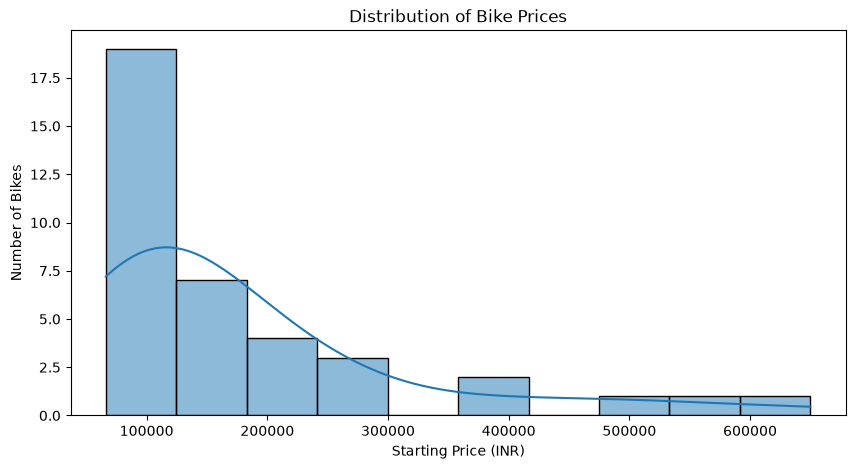

In [77]:
plt.figure(figsize=(10, 5))

sns.histplot(
    final_df["Price_INR"],
    bins=10,
    kde=True
)

plt.title("Distribution of Bike Prices")
plt.xlabel("Starting Price (INR)")
plt.ylabel("Number of Bikes")

plt.show()

In [78]:
print("Mean Price:", final_df["Price_INR"].mean())
print("Median Price:", final_df["Price_INR"].median())
print("Minimum Price:", final_df["Price_INR"].min())
print("Maximum Price:", final_df["Price_INR"].max())

Mean Price: 180665.73684210525
Median Price: 126631.0
Minimum Price: 66200
Maximum Price: 650000


“The price distribution is positively skewed. Most bikes in the dataset are concentrated in the lower-to-mid price range, while a smaller number of premium bikes have substantially higher prices. The mean price of approximately ₹1.81 lakh is higher than the median price of ₹1.27 lakh, which also indicates right skewness.”

Why we used this plot

“I used a histogram because it helps understand the distribution and concentration of bike prices and shows whether the data is symmetric or skewed.”

#### Price Boxplot

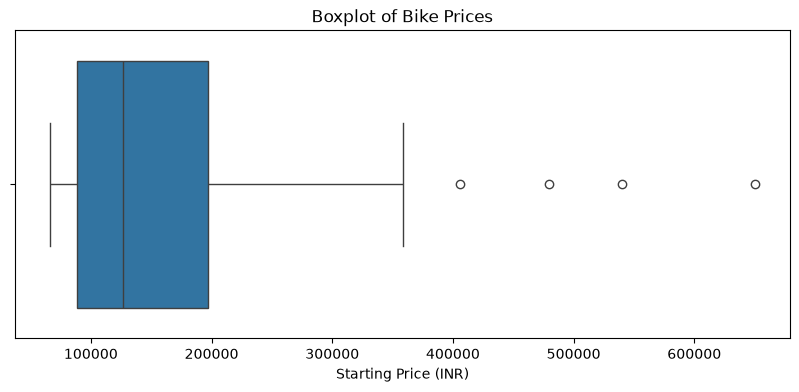

In [79]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=final_df["Price_INR"])

plt.title("Boxplot of Bike Prices")
plt.xlabel("Starting Price (INR)")

plt.show()

What it shows

The boxplot confirms the right-skewed price distribution we saw in the histogram.

Most bike prices fall roughly between ₹88K and ₹197K.
The median is around ₹1.27 lakh.
There are four points beyond the upper whisker.
These correspond to the premium bikes we already inspected.
We are retaining them because they are legitimate observations, not obvious data errors.
Presentation explanation

“The boxplot shows that most bike prices are concentrated in the lower and mid-price range, while a few premium bikes appear as high-value observations. These observations were investigated and retained because they represent genuine bike prices rather than data errors.”

Why use a boxplot?

“I used a boxplot to understand the spread of prices and identify potential extreme observations using the IQR method.”

#### Engine Capacity — Univariate Analysis

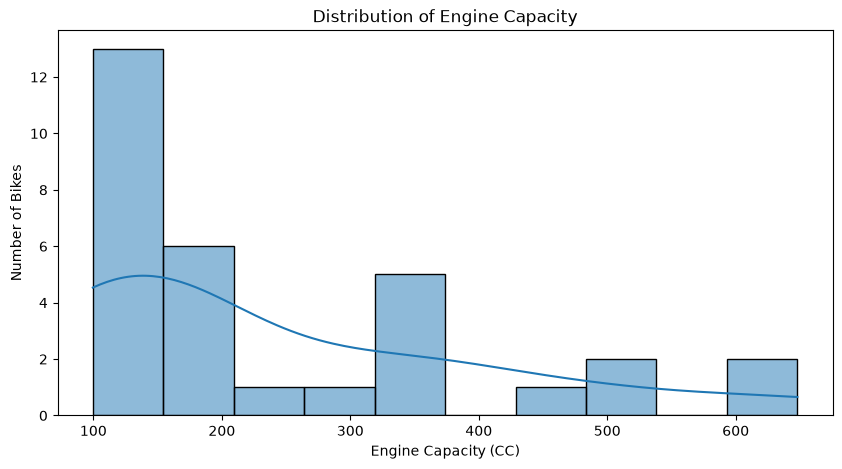

In [80]:
plt.figure(figsize=(10, 5))

sns.histplot(
    final_df["Engine_CC"].dropna(),
    bins=10,
    kde=True
)

plt.title("Distribution of Engine Capacity")
plt.xlabel("Engine Capacity (CC)")
plt.ylabel("Number of Bikes")

plt.show()

In [81]:
print("Mean Engine CC:", final_df["Engine_CC"].mean())
print("Median Engine CC:", final_df["Engine_CC"].median())
print("Minimum Engine CC:", final_df["Engine_CC"].min())
print("Maximum Engine CC:", final_df["Engine_CC"].max())

Mean Engine CC: 244.41193548387096
Median Engine CC: 159.7
Minimum Engine CC: 99.59
Maximum Engine CC: 648.0


Engine CC observations

From the 31 bikes with available engine-capacity data:

Mean: 244.41 CC
Median: 159.7 CC
Minimum: 99.59 CC
Maximum: 648 CC

The distribution is right-skewed. Most observations are concentrated around the lower engine-capacity range, while a smaller number of bikes have larger engines around 350–650 CC.

The mean being considerably higher than the median is consistent with those higher-capacity bikes pulling the average upward.

Presentation explanation

“The engine-capacity distribution is right-skewed. Most bikes have relatively smaller engine capacities, while a smaller number of bikes have larger engines extending up to 648 CC. The mean engine capacity is approximately 244 CC, whereas the median is 159.7 CC.”

Why this plot?

“I used a histogram to understand the distribution of engine capacities and identify the engine-size ranges that are most common in the scraped dataset.”

#### Engine Capacity Boxplot

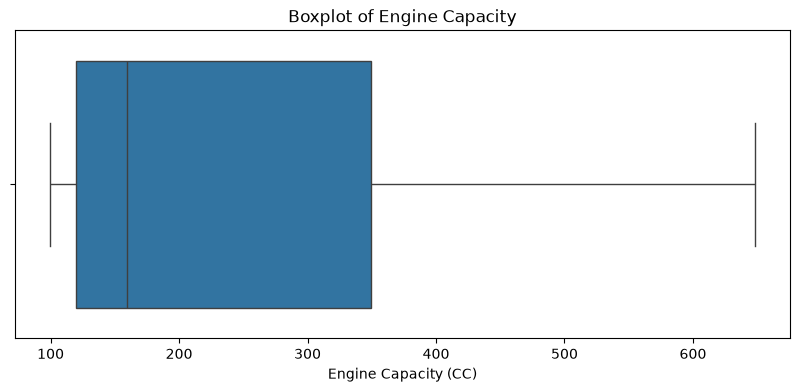

In [82]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=final_df["Engine_CC"])

plt.title("Boxplot of Engine Capacity")
plt.xlabel("Engine Capacity (CC)")

plt.show()

What it shows
The median is around 159.7 CC.
The middle 50% of observed bikes extends roughly from 120 CC to 349 CC.
The distribution has a long upper spread toward 648 CC.
There are no IQR outliers according to our earlier calculation.
Presentation explanation

“The engine-capacity boxplot shows a wide spread in engine sizes. The median is approximately 159.7 CC, while the upper range extends to 648 CC. The boxplot does not identify any statistical outliers using the IQR method.”

Why use a boxplot?

“The boxplot helps summarize the central tendency and spread of engine capacity and provides a visual check for potential outliers.”

#### Mileage Distribution

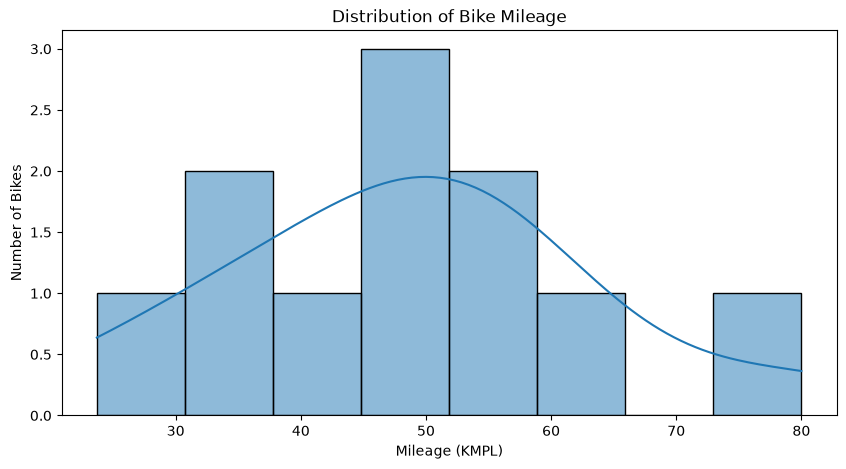

In [83]:
plt.figure(figsize=(10, 5))

sns.histplot(
    final_df["Mileage_KMPL"].dropna(),
    bins=8,
    kde=True
)

plt.title("Distribution of Bike Mileage")
plt.xlabel("Mileage (KMPL)")
plt.ylabel("Number of Bikes")

plt.show()

In [84]:
print("Mean Mileage:", final_df["Mileage_KMPL"].mean())
print("Median Mileage:", final_df["Mileage_KMPL"].median())
print("Minimum Mileage:", final_df["Mileage_KMPL"].min())
print("Maximum Mileage:", final_df["Mileage_KMPL"].max())
print("Available Mileage Records:", final_df["Mileage_KMPL"].notna().sum())

Mean Mileage: 48.930909090909104
Median Mileage: 50.0
Minimum Mileage: 23.7
Maximum Mileage: 80.0
Available Mileage Records: 11


Mileage observations

You have only 11 valid mileage records, so this analysis should be presented with that limitation.

Mean: 48.93 kmpl
Median: 50.00 kmpl
Minimum: 23.70 kmpl
Maximum: 80.00 kmpl
Available records: 11 out of 38

The values are broadly concentrated around 40–60 kmpl, with the highest observed value being 80 kmpl.

Because the sample is only 11 bikes, we should avoid making a strong claim that this represents the entire Indian bike market.

Presentation explanation

“The mileage distribution is based on 11 available observations. Most of the observed bikes have mileage between approximately 40 and 60 kmpl. The mean mileage is 48.93 kmpl and the median is 50 kmpl. Since many mileage values were unavailable in the scraped dataset, this analysis should be interpreted with caution.”

Why use a histogram?

“I used a histogram to understand the distribution of the available mileage values and identify the range in which most observations are concentrated.”

#### Mileage Boxplot

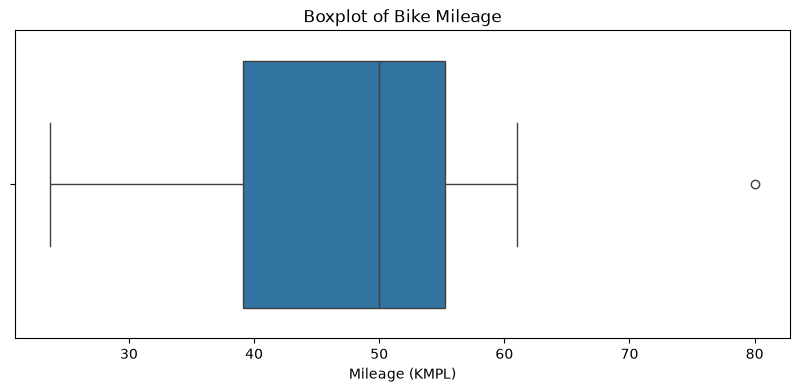

In [85]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=final_df["Mileage_KMPL"])

plt.title("Boxplot of Bike Mileage")
plt.xlabel("Mileage (KMPL)")

plt.show()

What it shows
Median mileage ≈ 50 kmpl
Most available observations are roughly between 39 and 55 kmpl
80 kmpl appears as a statistical outlier
We already inspected it and decided to retain it as a valid observed value.
Remember: only 11 of 38 bikes have mileage data.
Presentation explanation

“The mileage boxplot shows that the median mileage is around 50 kmpl, with most available observations concentrated between approximately 39 and 55 kmpl. The 80 kmpl observation is flagged statistically as an outlier, but it was retained because it is a valid observed value. The analysis is limited by the availability of mileage data for only 11 bikes.”

Why use a boxplot?

“The boxplot helps understand the spread of mileage and identify potential extreme observations using the IQR method.”

#### Power Distribution

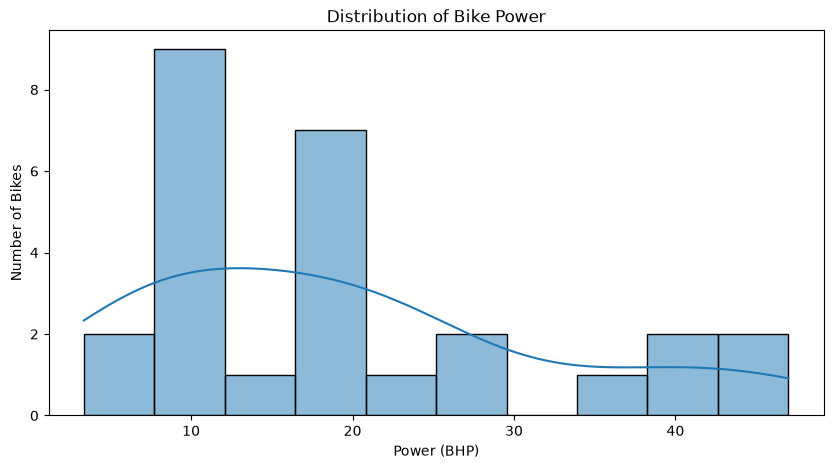

In [86]:
plt.figure(figsize=(10, 5))

sns.histplot(
    final_df["Power_BHP"].dropna(),
    bins=10,
    kde=True
)

plt.title("Distribution of Bike Power")
plt.xlabel("Power (BHP)")
plt.ylabel("Number of Bikes")

plt.show()

In [87]:
print("Mean Power:", final_df["Power_BHP"].mean())
print("Median Power:", final_df["Power_BHP"].median())
print("Minimum Power:", final_df["Power_BHP"].min())
print("Maximum Power:", final_df["Power_BHP"].max())
print("Available Power Records:", final_df["Power_BHP"].notna().sum())

Mean Power: 19.552067851851852
Median Power: 18.1
Minimum Power: 3.3525500000000004
Maximum Power: 47.0
Available Power Records: 27


Power observations

From the 27 bikes with available power data:

Mean: 19.55 BHP
Median: 18.10 BHP
Minimum: 3.35 BHP
Maximum: 47.00 BHP

The distribution is concentrated around the lower-to-mid power range, with fewer bikes extending into the 30–47 BHP range.

The lower values include the electric bikes whose power was converted from kW to BHP, so they should not automatically be considered errors.

Presentation explanation

“The power distribution is concentrated mainly between approximately 8 and 20 BHP, with fewer bikes having higher power levels. The mean power is 19.55 BHP and the median is 18.10 BHP. The maximum observed power is 47 BHP.”

Why this plot?

“I used a histogram to understand the distribution of available engine power and identify the power ranges most commonly represented in the dataset.”

#### Power Boxplot

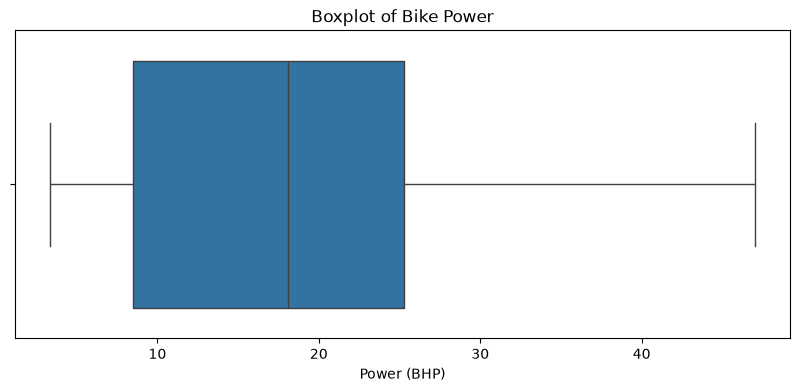

In [88]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=final_df["Power_BHP"])

plt.title("Boxplot of Bike Power")
plt.xlabel("Power (BHP)")

plt.show()

Power boxplot observation
Median power ≈ 18.1 BHP
The middle 50% is approximately 8.48–25.3 BHP
The observed range is 3.35–47 BHP
Our IQR test found no statistical outliers for Power.
Presentation explanation

“The power boxplot shows that the median power is approximately 18.1 BHP, with the middle 50% of observations ranging from about 8.48 to 25.3 BHP. The observed power values range from 3.35 to 47 BHP, and no statistical outliers were detected using the IQR method.”

#### Weight Distribution

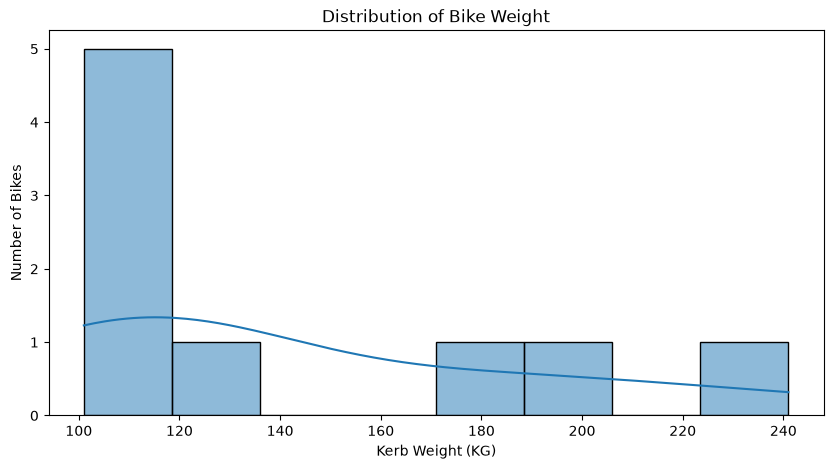

In [89]:
plt.figure(figsize=(10, 5))

sns.histplot(
    final_df["Weight_KG"].dropna(),
    bins=8,
    kde=True
)

plt.title("Distribution of Bike Weight")
plt.xlabel("Kerb Weight (KG)")
plt.ylabel("Number of Bikes")

plt.show()

In [90]:
print("Mean Weight:", final_df["Weight_KG"].mean())
print("Median Weight:", final_df["Weight_KG"].median())
print("Minimum Weight:", final_df["Weight_KG"].min())
print("Maximum Weight:", final_df["Weight_KG"].max())
print("Available Weight Records:", final_df["Weight_KG"].notna().sum())

Mean Weight: 143.33333333333334
Median Weight: 118.0
Minimum Weight: 101.0
Maximum Weight: 241.0
Available Weight Records: 9


Weight observations

From the 9 bikes with available weight data:

Mean: 143.33 kg
Median: 118 kg
Minimum: 101 kg
Maximum: 241 kg

The distribution is right-skewed: most of the available bikes are around 101–120 kg, while a few heavier bikes extend to 241 kg.

Because only 9 of 38 bikes have weight data, this is a limited observation and should be stated in the presentation.

Presentation explanation

“The weight distribution is right-skewed. Most of the available observations are concentrated around 101 to 120 kg, while a few heavier bikes extend up to 241 kg. The mean weight is 143.33 kg and the median is 118 kg. However, only 9 bikes have available weight information, so this result should be interpreted cautiously.”

Why use a histogram?

“I used a histogram to understand the distribution of the available bike weights and identify the range where most observations are concentrated.”

#### Weight Boxplot

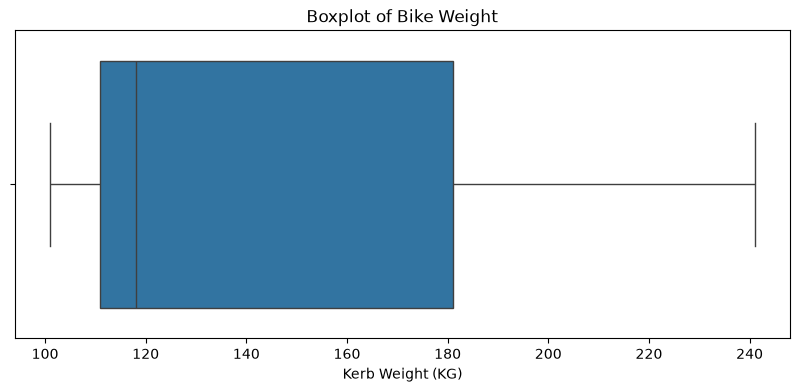

In [91]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=final_df["Weight_KG"])

plt.title("Boxplot of Bike Weight")
plt.xlabel("Kerb Weight (KG)")

plt.show()

Weight boxplot observation
Median ≈ 118 kg
Middle 50% is approximately 111–181 kg
Range: 101–241 kg
No statistical outliers were detected using the IQR method.
Only 9 of 38 bikes have weight data.
Presentation explanation

“The boxplot shows a median kerb weight of approximately 118 kg. The middle 50% of available observations lies between about 111 and 181 kg, with values ranging from 101 to 241 kg. No statistical outliers were detected using the IQR method. However, only 9 bikes had available weight information.”

Why use a boxplot?

“The boxplot helps summarize the spread of bike weights and check for potential extreme observations.”

#### Rating Distribution

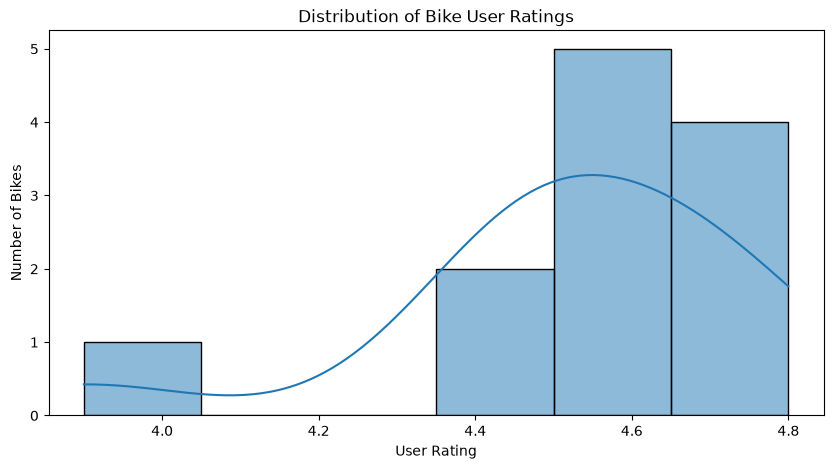

In [92]:
plt.figure(figsize=(10, 5))

sns.histplot(
    final_df["Rating"].dropna(),
    bins=6,
    kde=True
)

plt.title("Distribution of Bike User Ratings")
plt.xlabel("User Rating")
plt.ylabel("Number of Bikes")

plt.show()

In [93]:
print("Mean Rating:", final_df["Rating"].mean())
print("Median Rating:", final_df["Rating"].median())
print("Minimum Rating:", final_df["Rating"].min())
print("Maximum Rating:", final_df["Rating"].max())
print("Available Rating Records:", final_df["Rating"].notna().sum())

Mean Rating: 4.516666666666667
Median Rating: 4.5
Minimum Rating: 3.9
Maximum Rating: 4.8
Available Rating Records: 12


Rating observations

From the 12 bikes with available ratings:

Mean: 4.52
Median: 4.50
Minimum: 3.9
Maximum: 4.8

Most available ratings are concentrated between 4.4 and 4.8, with the majority around 4.5–4.7. The 3.9 rating belongs to TVS iQube and was already identified as a statistical outlier, but we retained it because it is a valid observed rating.

Presentation explanation

“The user-rating distribution is concentrated toward the higher end of the rating scale. Among the 12 available ratings, the mean is 4.52 and the median is 4.5. Ratings range from 3.9 to 4.8. The 3.9 rating was flagged by the IQR method but was retained because it is a valid observed rating.”

Important limitation

Only 12 out of 38 bikes have rating data in our current scraped dataset. Therefore, we should present this as a finding within the available observations, not as a conclusion about all bikes on BikeWale.

Why this plot?

“I used a histogram to understand how the available user ratings are distributed and whether ratings are concentrated around a particular range.”

#### Rating Boxplot

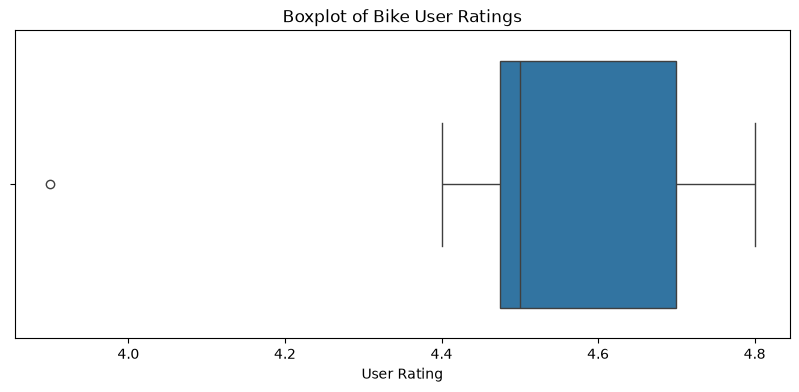

In [94]:
plt.figure(figsize=(10, 4))

sns.boxplot(x=final_df["Rating"])

plt.title("Boxplot of Bike User Ratings")
plt.xlabel("User Rating")

plt.show()

Rating boxplot observation
Median: 4.5
Middle 50%: approximately 4.48–4.70
Range: 3.9–4.8
3.9 is flagged as an IQR outlier.
We retain 3.9 because it is a valid observed rating, not a data error.
Only 12 of 38 bikes have rating data.
Presentation explanation

“The boxplot shows that the median user rating is 4.5, with most available ratings concentrated between approximately 4.5 and 4.7. The 3.9 rating appears as a statistical outlier, but it was retained because it is a valid observed rating. Only 12 bikes had available rating information in the scraped dataset.”

### Brand Distribution

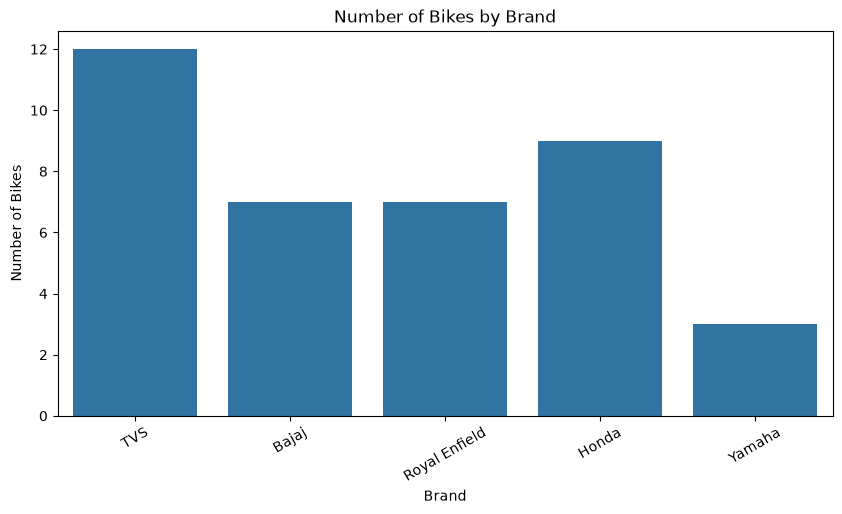

In [95]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=final_df,
    x="Brand"
)

plt.title("Number of Bikes by Brand")
plt.xlabel("Brand")
plt.ylabel("Number of Bikes")

plt.xticks(rotation=30)

plt.show()

In [96]:
print(final_df["Brand"].value_counts())

Brand
TVS              12
Honda             9
Bajaj             7
Royal Enfield     7
Yamaha            3
Name: count, dtype: int64


Important: this describes the composition of our scraped sample, not the overall Indian bike market.

Presentation explanation

“The brand distribution shows that TVS has the highest representation with 12 bikes, followed by Honda with 9, Bajaj and Royal Enfield with 7 each, and Yamaha with 3. This distribution reflects the bikes collected from the selected BikeWale pages and should not be interpreted as market share.”

Why use a count plot?

“I used a count plot because Brand is a categorical variable. The plot makes it easy to compare how many bike records belong to each brand.”

##### Univariate EDA is now complete

We have covered:

Price — histogram + boxplot
Engine Capacity — histogram + boxplot
Mileage — histogram + boxplot
Power — histogram + boxplot
Weight — histogram + boxplot
User Rating — histogram + boxplot
Brand — count plot

## Bivariate EDA

#### Price vs Engine Capacity

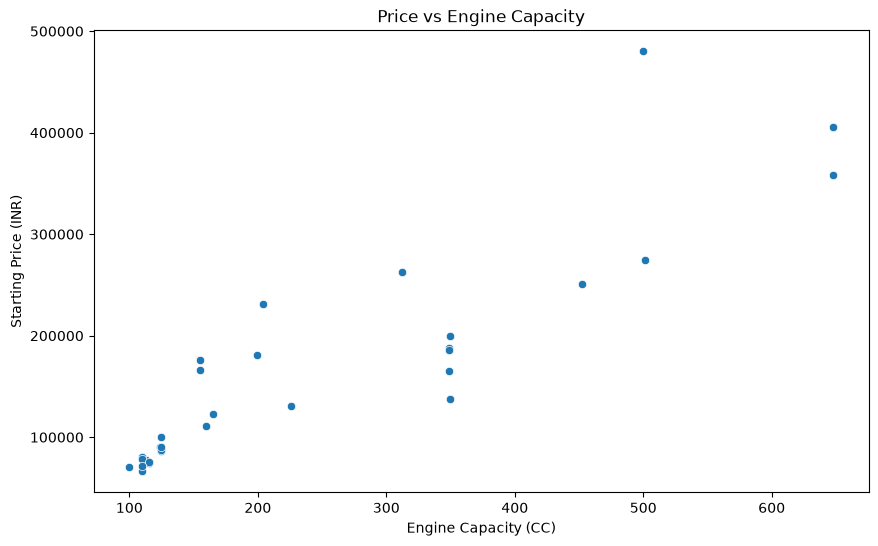

In [97]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=final_df,
    x="Engine_CC",
    y="Price_INR"
)

plt.title("Price vs Engine Capacity")
plt.xlabel("Engine Capacity (CC)")
plt.ylabel("Starting Price (INR)")

plt.show()

In [98]:
correlation = final_df["Engine_CC"].corr(final_df["Price_INR"])

print("Correlation between Engine CC and Price:", correlation)

Correlation between Engine CC and Price: 0.8888873984072632


Bivariate Analysis 1 — Price vs Engine Capacity

Correlation = 0.889

This indicates a strong positive linear association in our scraped dataset: bikes with larger engine capacities generally tend to have higher starting prices.

The scatter plot also shows this pattern visually. The higher-CC bikes are generally positioned at higher price levels, although there is variation among bikes with similar engine capacities.

Presentation explanation

“I analyzed the relationship between starting price and engine capacity using a scatter plot and Pearson correlation. The correlation coefficient is approximately 0.889, indicating a strong positive relationship in this dataset. In general, bikes with larger engine capacities tend to have higher starting prices. However, correlation does not imply that engine capacity alone determines the price.”

Why this plot?

“I used a scatter plot because both price and engine capacity are numerical variables, and the plot helps visualize the direction and strength of their relationship.”

Data limitation: the correlation uses the 31 bikes with non-missing engine capacity, not all 38 bikes.

#### Bivariate Analysis 2 — Price vs Power

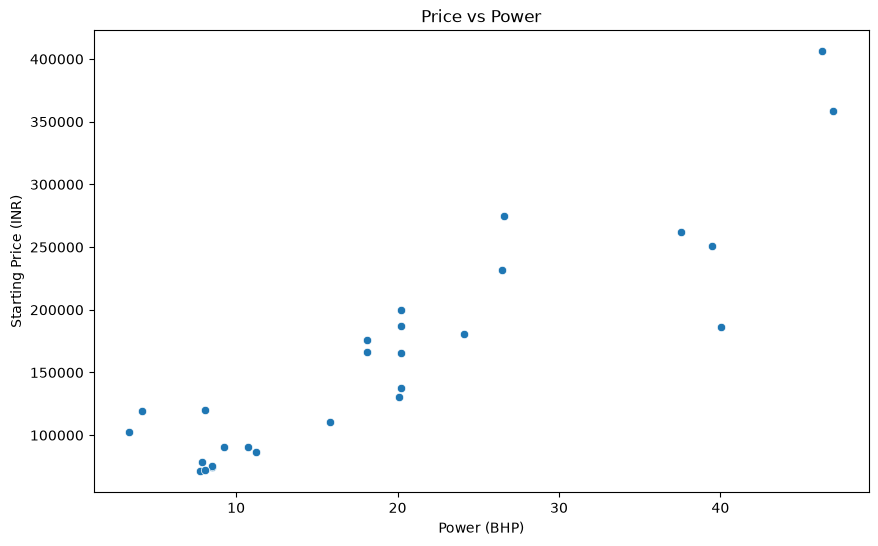

In [99]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=final_df,
    x="Power_BHP",
    y="Price_INR"
)

plt.title("Price vs Power")
plt.xlabel("Power (BHP)")
plt.ylabel("Starting Price (INR)")

plt.show()

In [100]:
correlation_power_price = final_df["Power_BHP"].corr(
    final_df["Price_INR"]
)

print(
    "Correlation between Power and Price:",
    correlation_power_price
)

Correlation between Power and Price: 0.9039986193189437


#### Bivariate Analysis 2 — Price vs Power

Correlation = 0.904

This indicates a strong positive association between power and starting price in our available observations.

The scatter plot also shows that bikes with higher power generally appear at higher price levels, although there are exceptions.

Presentation explanation

“I analyzed the relationship between starting price and power using a scatter plot and Pearson correlation. The correlation coefficient is approximately 0.904, indicating a strong positive relationship in this dataset. In general, bikes with higher power tend to have higher starting prices. However, power alone does not determine the price, as other features and factors can also contribute.”

Why this plot?

“I used a scatter plot because both variables are numerical. It helps visualize whether changes in power are associated with changes in starting price.”

Data limitation: this correlation is based on the 27 bikes with available power values.

### Bivariate Analysis 3 — Price vs Rating

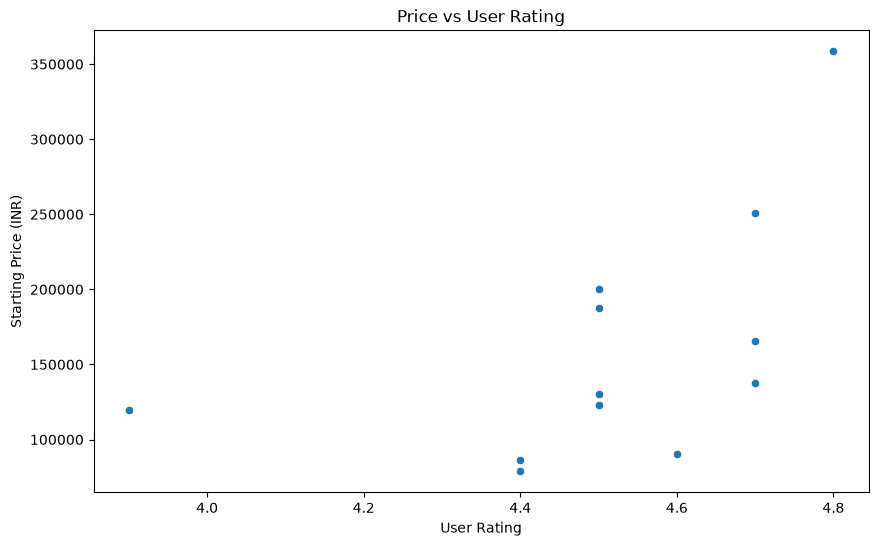

In [101]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=final_df,
    x="Rating",
    y="Price_INR"
)

plt.title("Price vs User Rating")
plt.xlabel("User Rating")
plt.ylabel("Starting Price (INR)")

plt.show()

In [102]:
correlation_rating_price = final_df["Rating"].corr(
    final_df["Price_INR"]
)

print(
    "Correlation between Rating and Price:",
    correlation_rating_price
)

Correlation between Rating and Price: 0.5195147194312905


#### Bivariate Analysis 3 — Price vs User Rating

Correlation = 0.520

This indicates a moderate positive relationship between user rating and starting price in the available records.

From the scatter plot, ratings are mostly concentrated between 4.4 and 4.8, while prices vary considerably. This suggests that rating alone does not explain the price differences.

Presentation explanation

“I analyzed the relationship between starting price and user rating using a scatter plot. The correlation is approximately 0.52, indicating a moderate positive relationship in the available data. However, the prices vary significantly even among bikes with similar ratings, so rating alone does not determine the starting price.”

Why this plot?

“I used a scatter plot because both price and rating are numerical variables, and it helps visualize their relationship and the spread of prices across different ratings.”

Important: Only 12 bikes have rating values, so mention this limitation during the presentation.

### Bivariate Analysis 4 — Brand vs Price

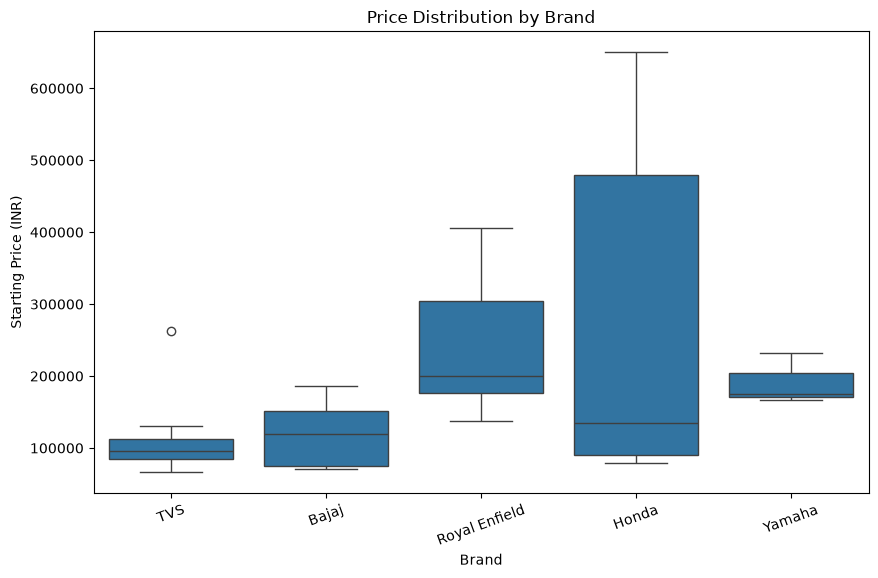

In [103]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=final_df,
    x="Brand",
    y="Price_INR"
)

plt.title("Price Distribution by Brand")
plt.xlabel("Brand")
plt.ylabel("Starting Price (INR)")
plt.xticks(rotation=20)

plt.show()

In [104]:
brand_price_summary = (
    final_df.groupby("Brand")["Price_INR"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

display(brand_price_summary)

,count,mean,median,min,max
Brand,,,,,
Bajaj,7,118683.43,119056.0,71049,186157
Honda,9,272162.22,135000.0,78693,650000
Royal Enfield,7,243742.57,199990.0,137640,405988
TVS,12,108771.83,95251.5,66200,262265
Yamaha,3,191198.00,175693.0,166400,231501


#### What the plot shows

The boxplot compares the starting-price distribution across the five brands.

TVS: ₹66,200–₹2,62,265; median ≈ ₹95,252
Bajaj: ₹71,049–₹1,86,157; median ≈ ₹1,19,056
Royal Enfield: ₹1,37,640–₹4,05,988; median ≈ ₹1,99,990
Honda: ₹78,693–₹6,50,000; median ≈ ₹1,35,000
Yamaha: ₹1,66,400–₹2,31,501; median ≈ ₹1,75,693
Presentation explanation

“I compared starting prices across brands using a boxplot. The plot shows substantial variation in price within and between brands. Honda has the widest price range in this dataset, while Yamaha has a relatively narrower range. Royal Enfield also shows a higher central price range compared with TVS and Bajaj.”

Why this plot?

“I used a boxplot because Brand is a categorical variable and Price is numerical. A boxplot allows us to compare the median, spread and potential extreme values across different brands.”

One important observation

TVS has a visible high-price observation around ₹2.62 lakh, while Honda has several much higher-priced observations. These are not automatically errors—they represent bikes at different price levels.

### Bivariate Analysis 5 — Engine Capacity vs Power

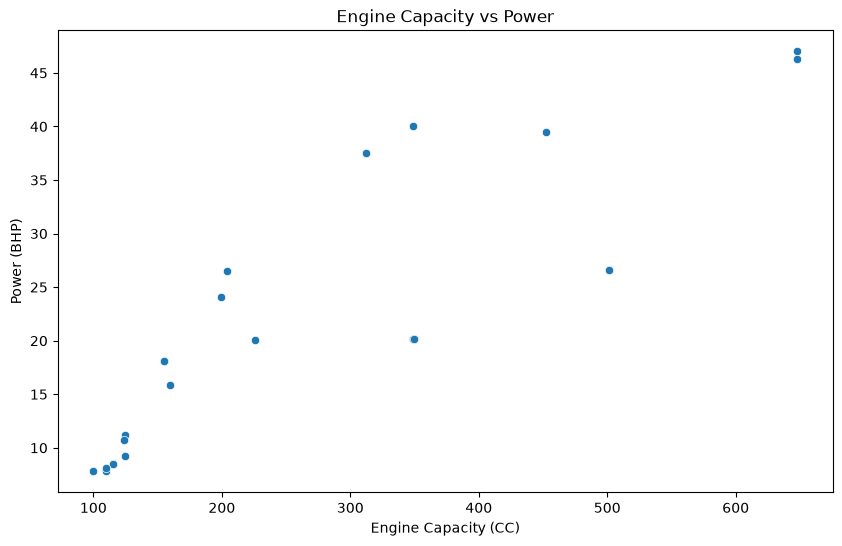

In [105]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=final_df,
    x="Engine_CC",
    y="Power_BHP"
)

plt.title("Engine Capacity vs Power")
plt.xlabel("Engine Capacity (CC)")
plt.ylabel("Power (BHP)")

plt.show()

In [106]:
correlation_engine_power = final_df["Engine_CC"].corr(
    final_df["Power_BHP"]
)

print("Correlation between Engine CC and Power:", correlation_engine_power)

Correlation between Engine CC and Power: 0.8670947522878671


#### Bivariate Analysis 5 — Engine Capacity vs Power is completed.

Result

Correlation = 0.867

This indicates a strong positive relationship between engine capacity and power in the available records.

From the scatter plot, higher engine-capacity bikes generally tend to have higher power, although there is some variation.

Presentation explanation

“I analyzed the relationship between engine capacity and engine power using a scatter plot. The correlation is approximately 0.87, showing a strong positive relationship in the available records. In general, bikes with larger engine capacities tend to produce higher power, although the relationship is not perfectly linear.”

Why this plot?

“I used a scatter plot because both engine capacity and power are numerical variables, and it helps visualize their relationship and identify the overall trend.”

⚠️ Important limitation

Only records where both Engine_CC and Power_BHP are available are included in this correlation. Therefore, we should not describe it as representing all 38 bikes.

### Bivariate Analysis completed

We now have 5 useful bivariate analyses:

|Analysis	|Result |
|Price vs Engine CC	| 0.889|
Price vs Power	    |0.904
Price vs User Rating	|0.520
Brand vs Price	Boxplot comparison
Engine CC vs Power	0.867

## Multivariate Analysis

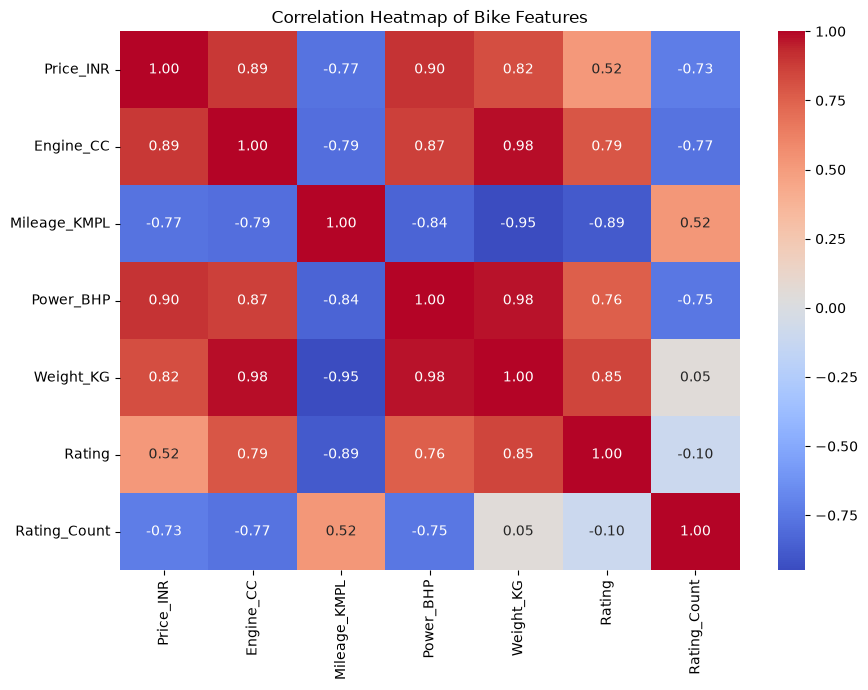

In [107]:
plt.figure(figsize=(10, 7))

correlation_matrix = final_df[
    [
        "Price_INR",
        "Engine_CC",
        "Mileage_KMPL",
        "Power_BHP",
        "Weight_KG",
        "Rating",
        "Rating_Count"
    ]
].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap of Bike Features")
plt.show()

#### Multivariate Analysis — Correlation Heatmap is completed.

Key observations from your heatmap
Price vs Power = 0.90
Strong positive relationship.
Higher-power bikes generally have higher prices in this dataset.
Price vs Engine CC = 0.89
Strong positive relationship.
Larger engine capacity generally corresponds to higher starting prices.
Engine CC vs Weight = 0.98
Very strong positive relationship.
Higher-engine-capacity bikes in this dataset generally have greater kerb weight.
Power vs Weight = 0.98
Very strong positive relationship.
Higher-power bikes generally tend to be heavier.
Mileage vs Weight = -0.95
Strong negative relationship.
Heavier bikes generally show lower mileage among the available records.
Mileage vs Power = -0.84
Strong negative relationship.
Higher-power bikes generally tend to have lower mileage.
Rating vs Price = 0.52
Moderate positive relationship.
Rating Count vs Price = -0.73
Negative relationship in this dataset: bikes with more recorded ratings tend to have lower starting prices.
Presentation explanation

“For multivariate analysis, I used a correlation heatmap to examine relationships among multiple numerical bike features simultaneously. The strongest relationships include engine capacity with weight at 0.98 and power with weight at 0.98. Price also has strong positive correlations with power at 0.90 and engine capacity at 0.89. Mileage shows strong negative relationships with weight and power. This helps us understand how different bike features interact rather than analyzing them individually.”

Why a heatmap?

“I used a correlation heatmap because it provides a compact view of relationships between multiple numerical variables. Positive correlations are shown on one side of the scale and negative correlations on the other, making strong relationships easy to identify.”

⚠️ Say this if asked about missing data

These correlations are calculated pairwise using the available values, so the number of observations can differ between feature pairs. Therefore, these relationships should be interpreted as patterns in the scraped dataset, not as causal relationships.

## Pivot Table Analysis

In [108]:
brand_pivot = pd.pivot_table(
    final_df,
    index="Brand",
    values=[
        "Price_INR",
        "Engine_CC",
        "Power_BHP",
        "Rating"
    ],
    aggfunc="mean"
).round(2)

display(brand_pivot)

,Engine_CC,Power_BHP,Price_INR,Rating
Brand,,,,
Bajaj,173.99,15.51,118683.43,4.50
Honda,268.89,13.31,272162.22,4.50
Royal Enfield,449.24,30.51,243742.57,4.65
TVS,152.97,15.05,108771.83,4.27
Yamaha,171.33,20.90,191198.00,NaN


Presentation explanation

“I created a pivot table to summarize the average engine capacity, power, starting price and user rating by brand. Royal Enfield has the highest average engine capacity and power among the brands in this dataset. TVS has the lowest average starting price, while Honda shows a relatively high average price because its dataset contains bikes across a wide price range. Yamaha's average rating is unavailable because rating data was missing for the available Yamaha records.”

Why use a pivot table?

“A pivot table helps summarize multiple numerical features by category. Instead of examining individual bike records, I can quickly compare the overall characteristics of each brand.”

In [109]:
insights_summary = pd.DataFrame({
    "Metric": [
        "Total Bikes",
        "Minimum Price",
        "Median Price",
        "Maximum Price",
        "Average Engine CC",
        "Average Mileage",
        "Average Power",
        "Average Weight",
        "Average Rating"
    ],
    "Value": [
        len(final_df),
        final_df["Price_INR"].min(),
        final_df["Price_INR"].median(),
        final_df["Price_INR"].max(),
        final_df["Engine_CC"].mean(),
        final_df["Mileage_KMPL"].mean(),
        final_df["Power_BHP"].mean(),
        final_df["Weight_KG"].mean(),
        final_df["Rating"].mean()
    ]
})

display(insights_summary.round(2))

,Metric,Value
0,Total Bikes,38.00
1,Minimum Price,66200.00
2,Median Price,126631.00
3,Maximum Price,650000.00
4,Average Engine CC,244.41
5,Average Mileage,48.93
6,Average Power,19.55
7,Average Weight,143.33
8,Average Rating,4.52


## Conclusion

The analysis of 38 bikes scraped from BikeWale shows that the Indian bike dataset contains a wide range of prices and specifications.

The starting price ranges from ₹66,200 to ₹6,50,000, with a median price of ₹1,26,631. Engine capacity and power show strong positive relationships with price, while mileage shows negative relationships with power, engine capacity and weight.

Brand-level analysis shows that the scraped bikes cover different price and performance segments. User ratings are generally high among the available rating records, although rating information was available for only a subset of bikes.

Overall, the analysis demonstrates that bike selection depends on multiple factors such as price, performance, mileage, weight and user ratings rather than a single feature.

## Limitations

1. The dataset contains only 38 validated bike records.
2. Some specifications were unavailable on the scraped pages.
3. Mileage, weight and rating data had substantial missing values.
4. The dataset represents a scraped sample and should not be considered a complete representation of the Indian bike market.
5. Correlation shows association, not causation.
6. The analysis does not produce one universally "best" bike because different buyers may prioritize different features.
7. The analysis reflects the data collected from BikeWale at the time of scraping.

## Future Improvements

1. Scrape a larger number of bike models.
2. Collect additional features such as fuel type, transmission, braking system and features.
3. Improve extraction of missing specifications.
4. Collect data from multiple reliable sources for broader comparison.
5. Build an interactive dashboard for easier bike comparison.